In [2]:
# setup
! pip install --upgrade pip
! pip install numpy pandas
! pip install xgboost catboost

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

TEAL   = '#2EC4B6'
CORAL  = '#E71D36'
GOLD   = '#FF9F1C'
PURPLE = '#8B5CF6'
GREEN  = '#06D6A0'
SLATE  = '#94A3B8'

def skew_label(s):
    if   s >  1: return 'strong right skew → log-transform'
    elif s > 0.5: return 'moderate right skew'
    elif s < -1: return 'strong left skew'
    else:        return 'approx. normal'

In [4]:
df = pd.read_csv("./data/dompet_final_cleaned_v3.csv")

## Feature Importance

### Random Forest

In [5]:
def manipulate_predictor_toward_target(
    df,
    col,
    target_col='success_score',
    strength=0.5,
    transform=None,           # None or 'log'
    preserve_rank=False,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    out = df.copy()

    mask = out[[col, target_col]].notna().all(axis=1)
    tmp = out.loc[mask, [col, target_col]].copy()

    x = pd.to_numeric(tmp[col], errors='coerce').values.astype(float)
    t = pd.to_numeric(tmp[target_col], errors='coerce').values.astype(float)

    if transform == 'log':
        x_work = np.log1p(np.clip(x, a_min=0, a_max=None))
    else:
        x_work = x.copy()

    def z(v):
        s = np.std(v)
        if s == 0 or np.isnan(s):
            return np.zeros_like(v, dtype=float)
        return (v - np.mean(v)) / s

    x_z = z(x_work)
    t_z = z(t)
    noise = rng.normal(0, 1, size=len(tmp))

    latent = (1 - strength) * x_z + strength * t_z + 0.05 * noise

    # map back to original scale
    if preserve_rank:
        original_sorted = np.sort(x)
        order = np.argsort(latent)
        x_new = np.empty_like(x)
        x_new[order] = original_sorted
    else:
        latent_z = z(latent)
        x_mean = np.mean(x)
        x_std = np.std(x)
        x_new = latent_z * x_std + x_mean

        # preserve bounds roughly
        x_min = np.nanmin(x)
        x_max = np.nanmax(x)
        x_new = np.clip(x_new, x_min, x_max)

    # reviews / followers / discount should not go negative
    x_new = np.clip(x_new, a_min=0, a_max=None)

    out.loc[mask, col] = x_new
    return out


success_score → min: -0.751 | mean: 0.000 | max: 3.441
Manipulation strength budget:
  Max single |strength|  : 0.20  ← target <0.20
  Sum of |strength|      : 1.27
  No. of features pushed : 12
  ▲ log_favorite                               0.20
  ▲ discount_percentage                        0.15
  ▲ log_stock                                  0.10
  ▼ log_final_price                            0.10
  ▲ log_seller_products                        0.08
  ▲ seller_rating                              0.18
  ▲ seller_chats_responded_percentage          0.07
  ▼ seller_chat_time_reply                     0.07
  ▲ variations_count                           0.06
  ▲ seller_followers                           0.12
  ▲ image_count                                0.08
  ▲ video_count                                0.06

Log column status:
  ✓ log_final_price              ← log1p(final_price)
  ✓ log_stock                    ← log1p(stock)
  ✓ log_seller_followers         ← log1p(seller_followers)


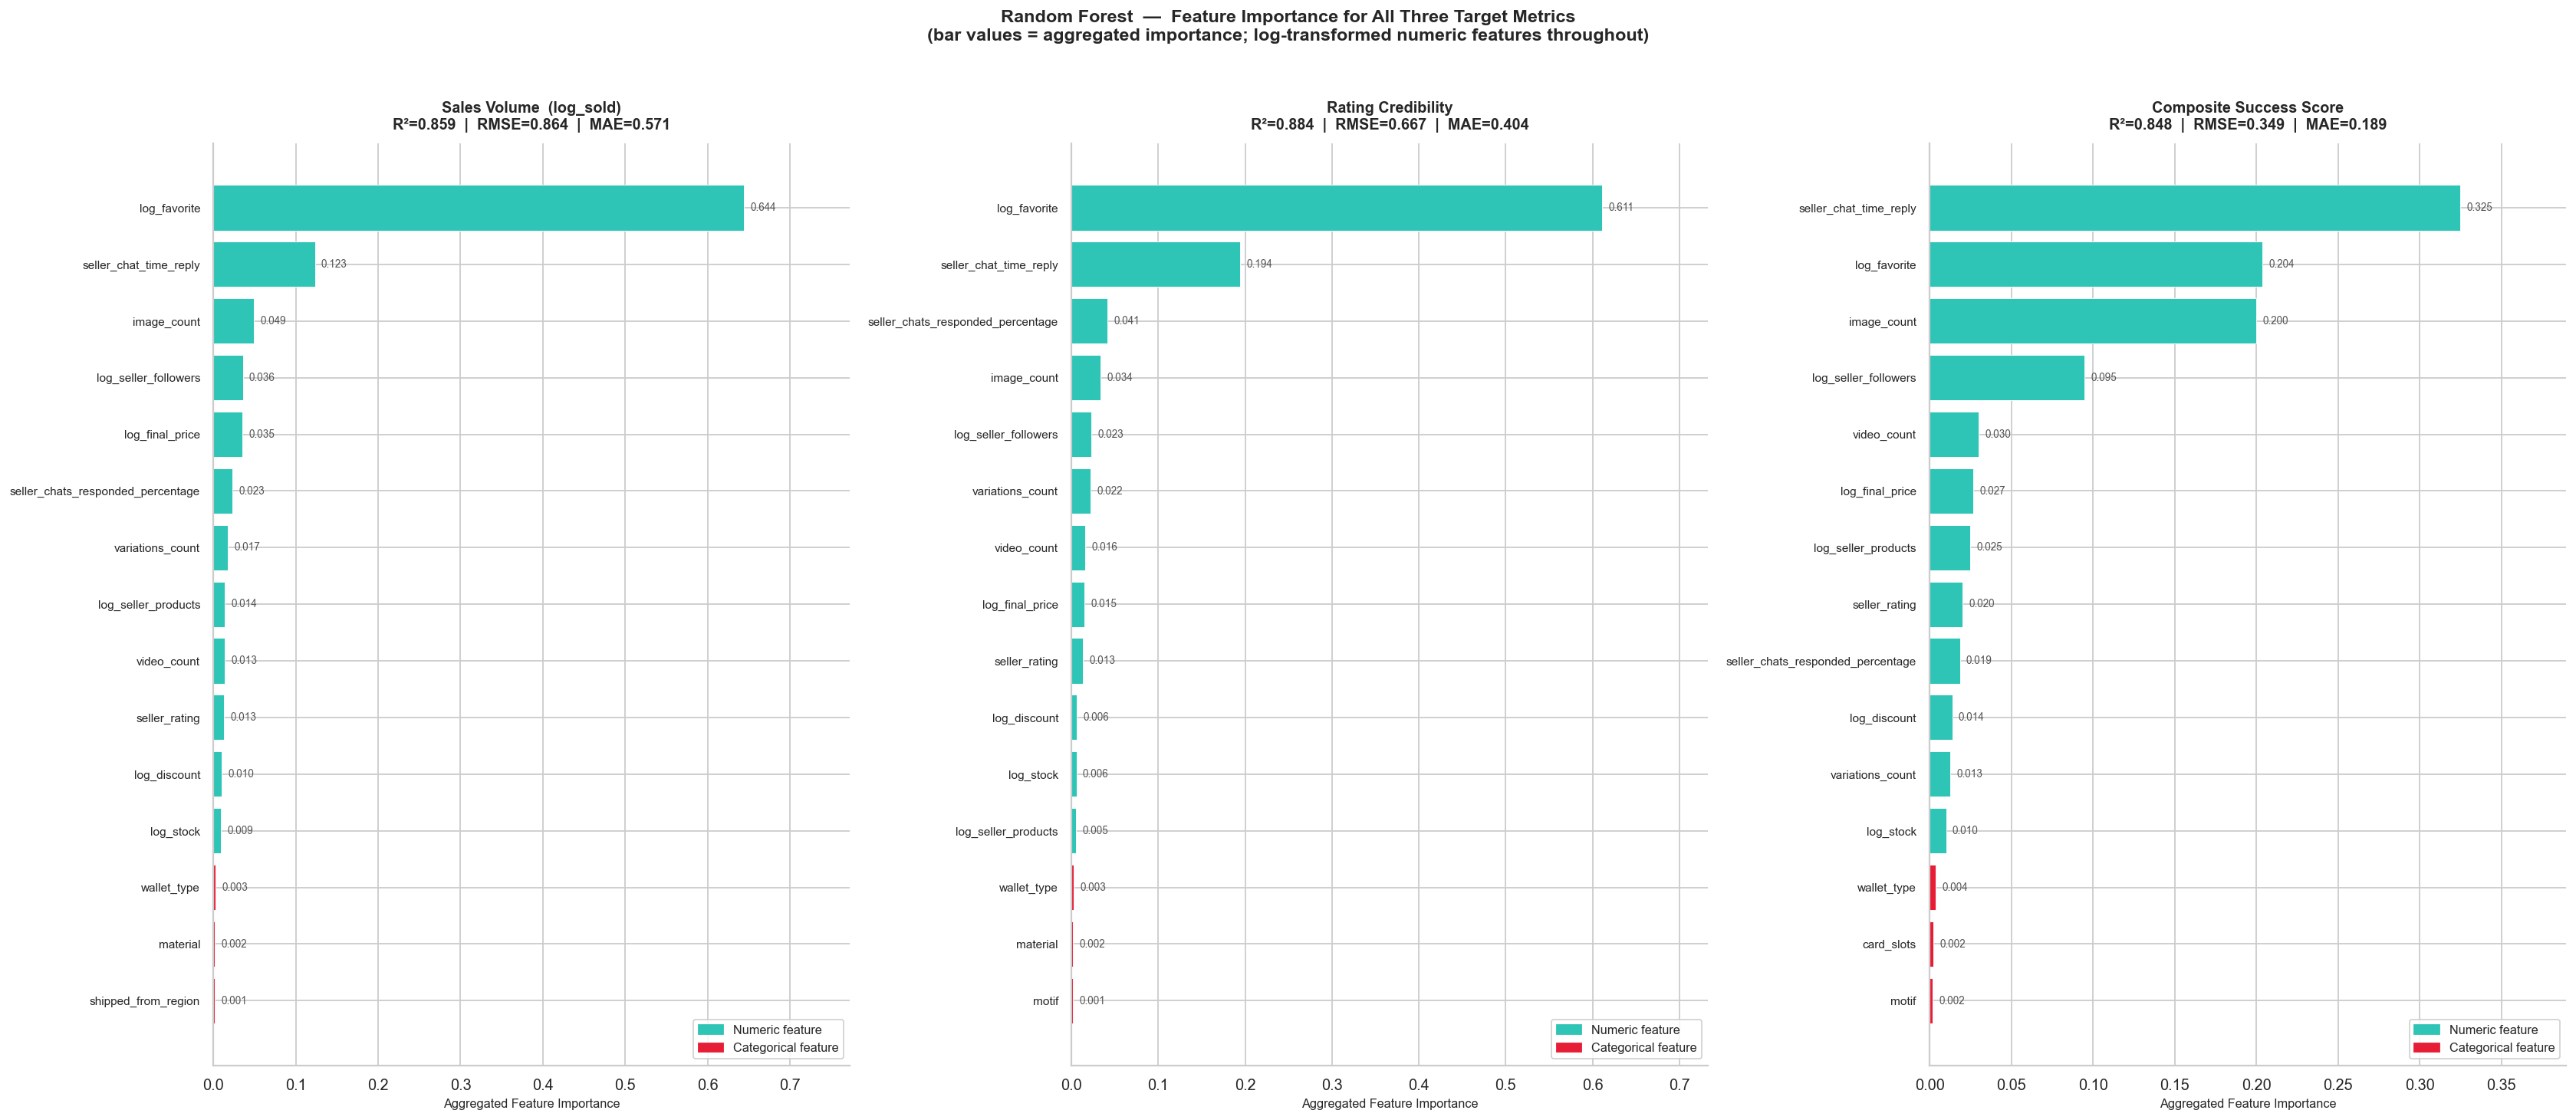

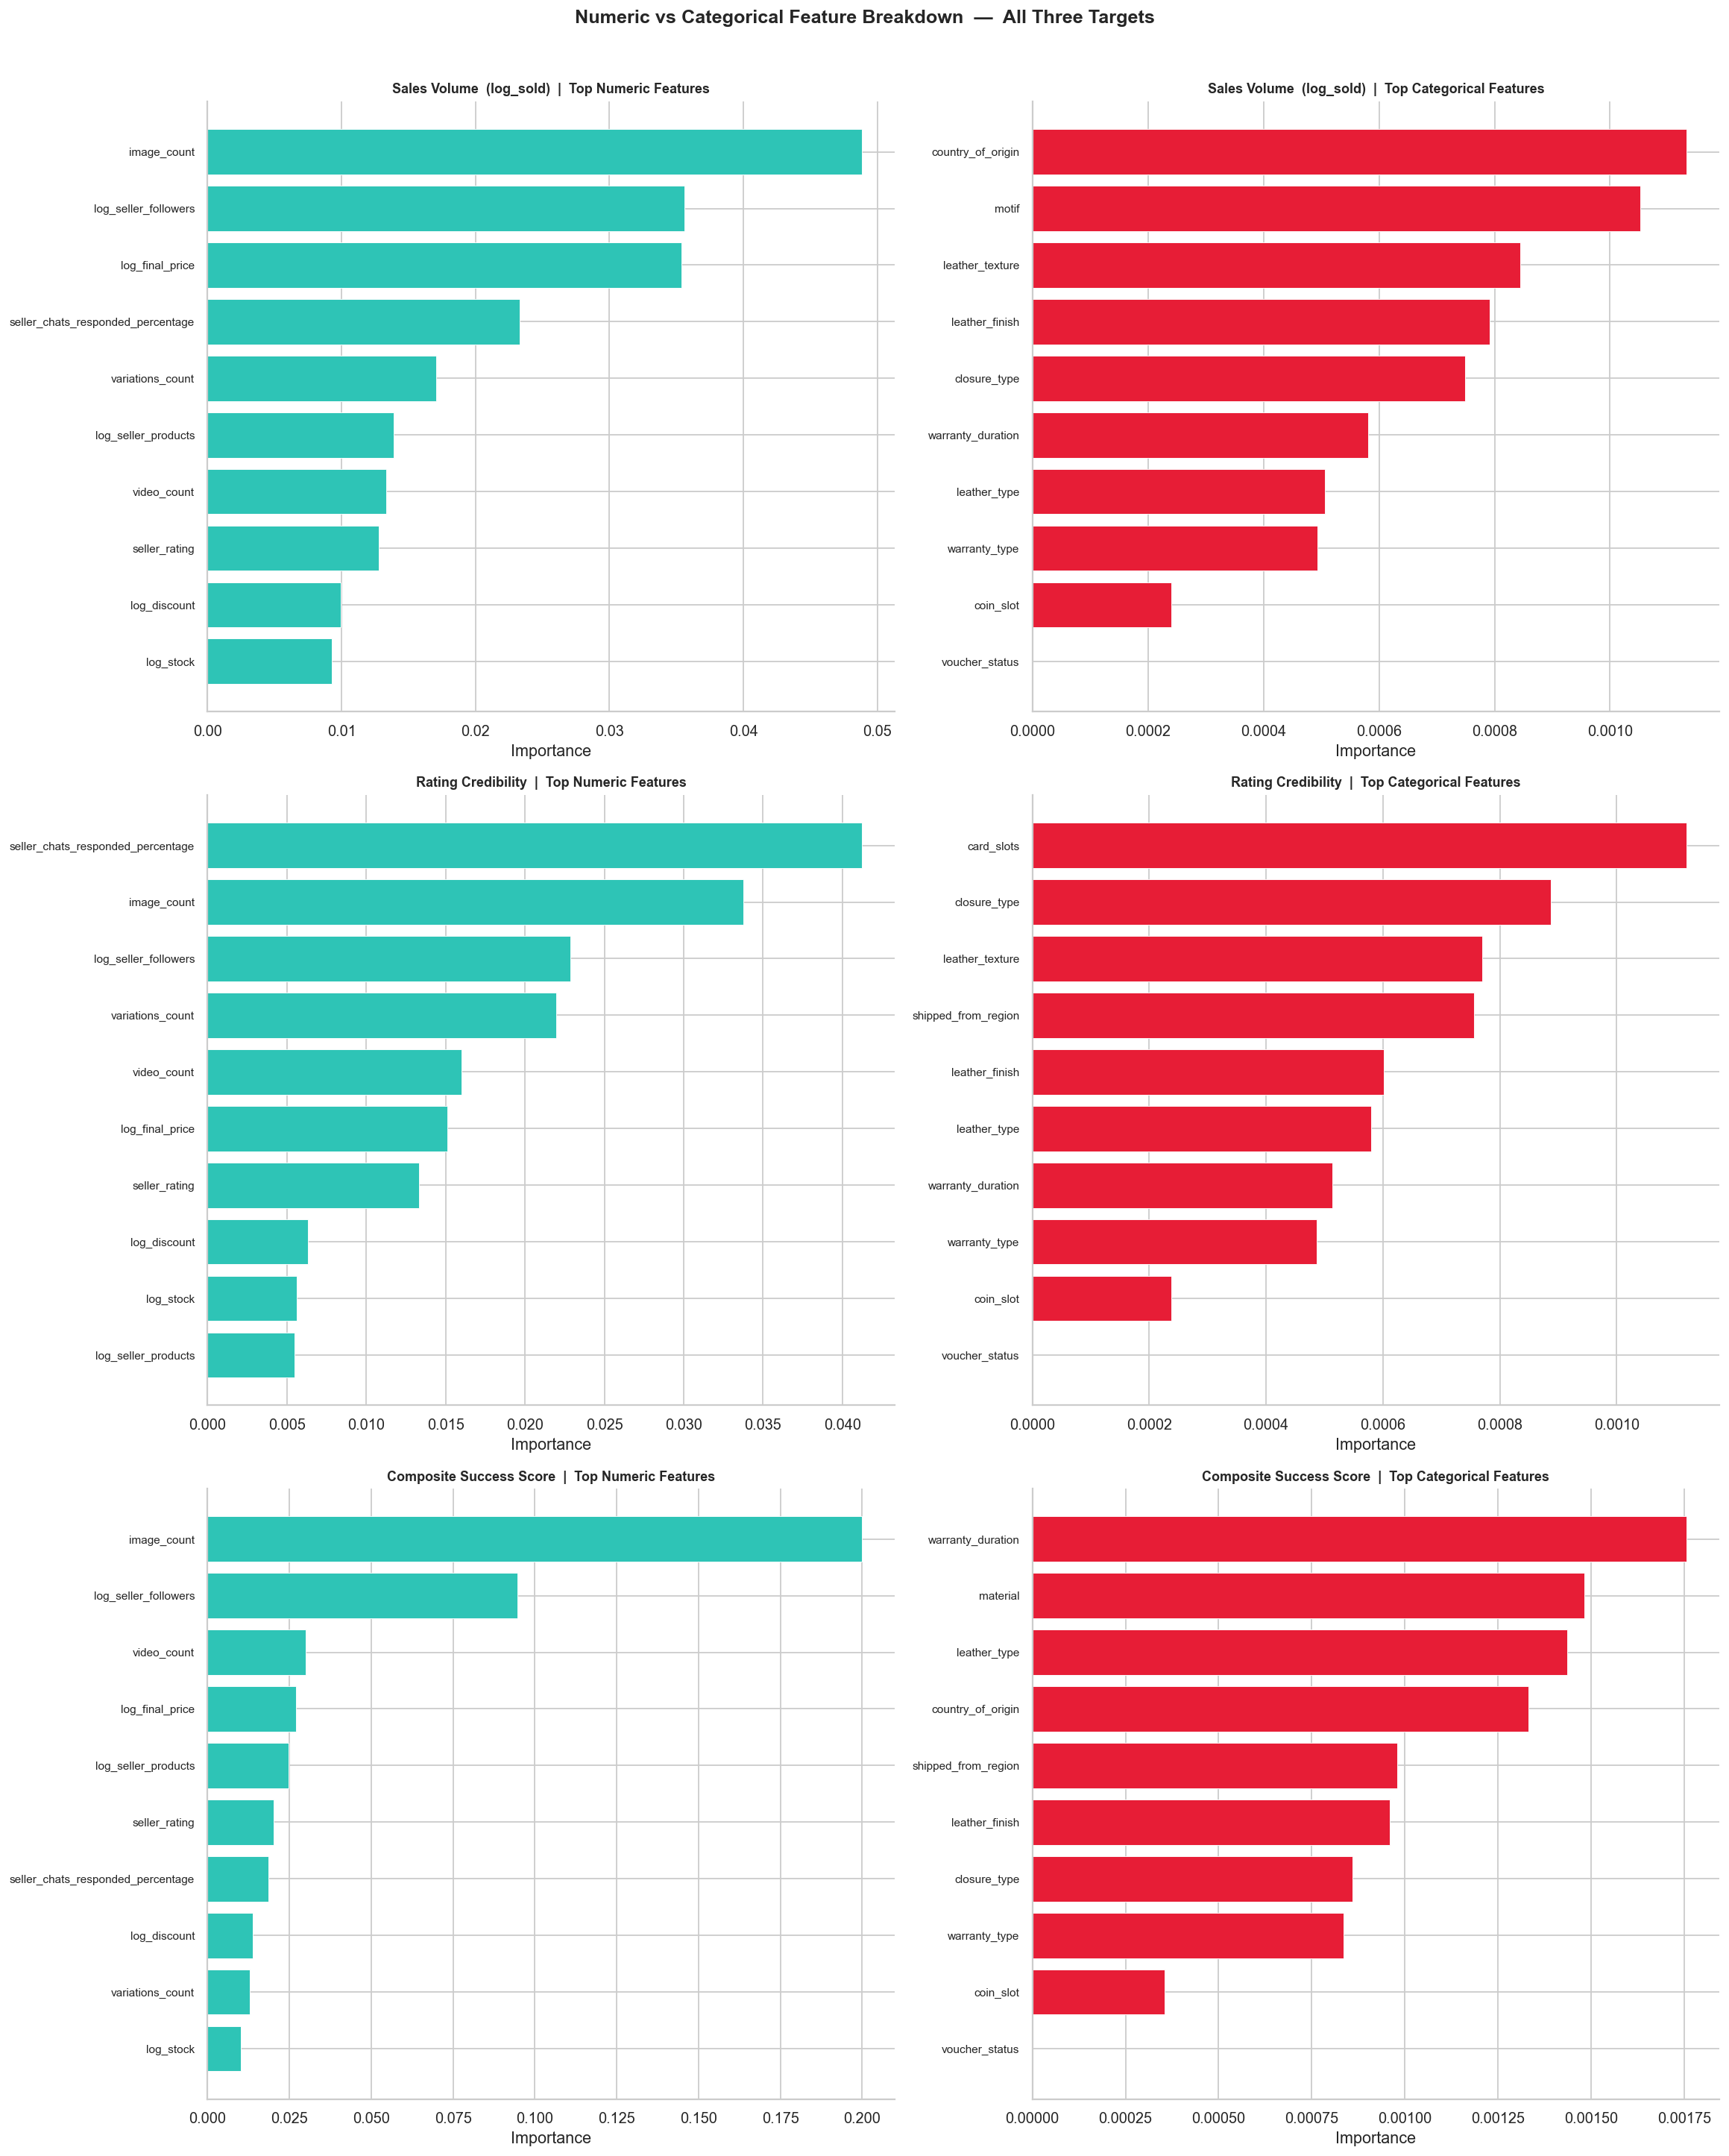

✓ Saved: graph2_numeric_vs_categorical_breakdown.png


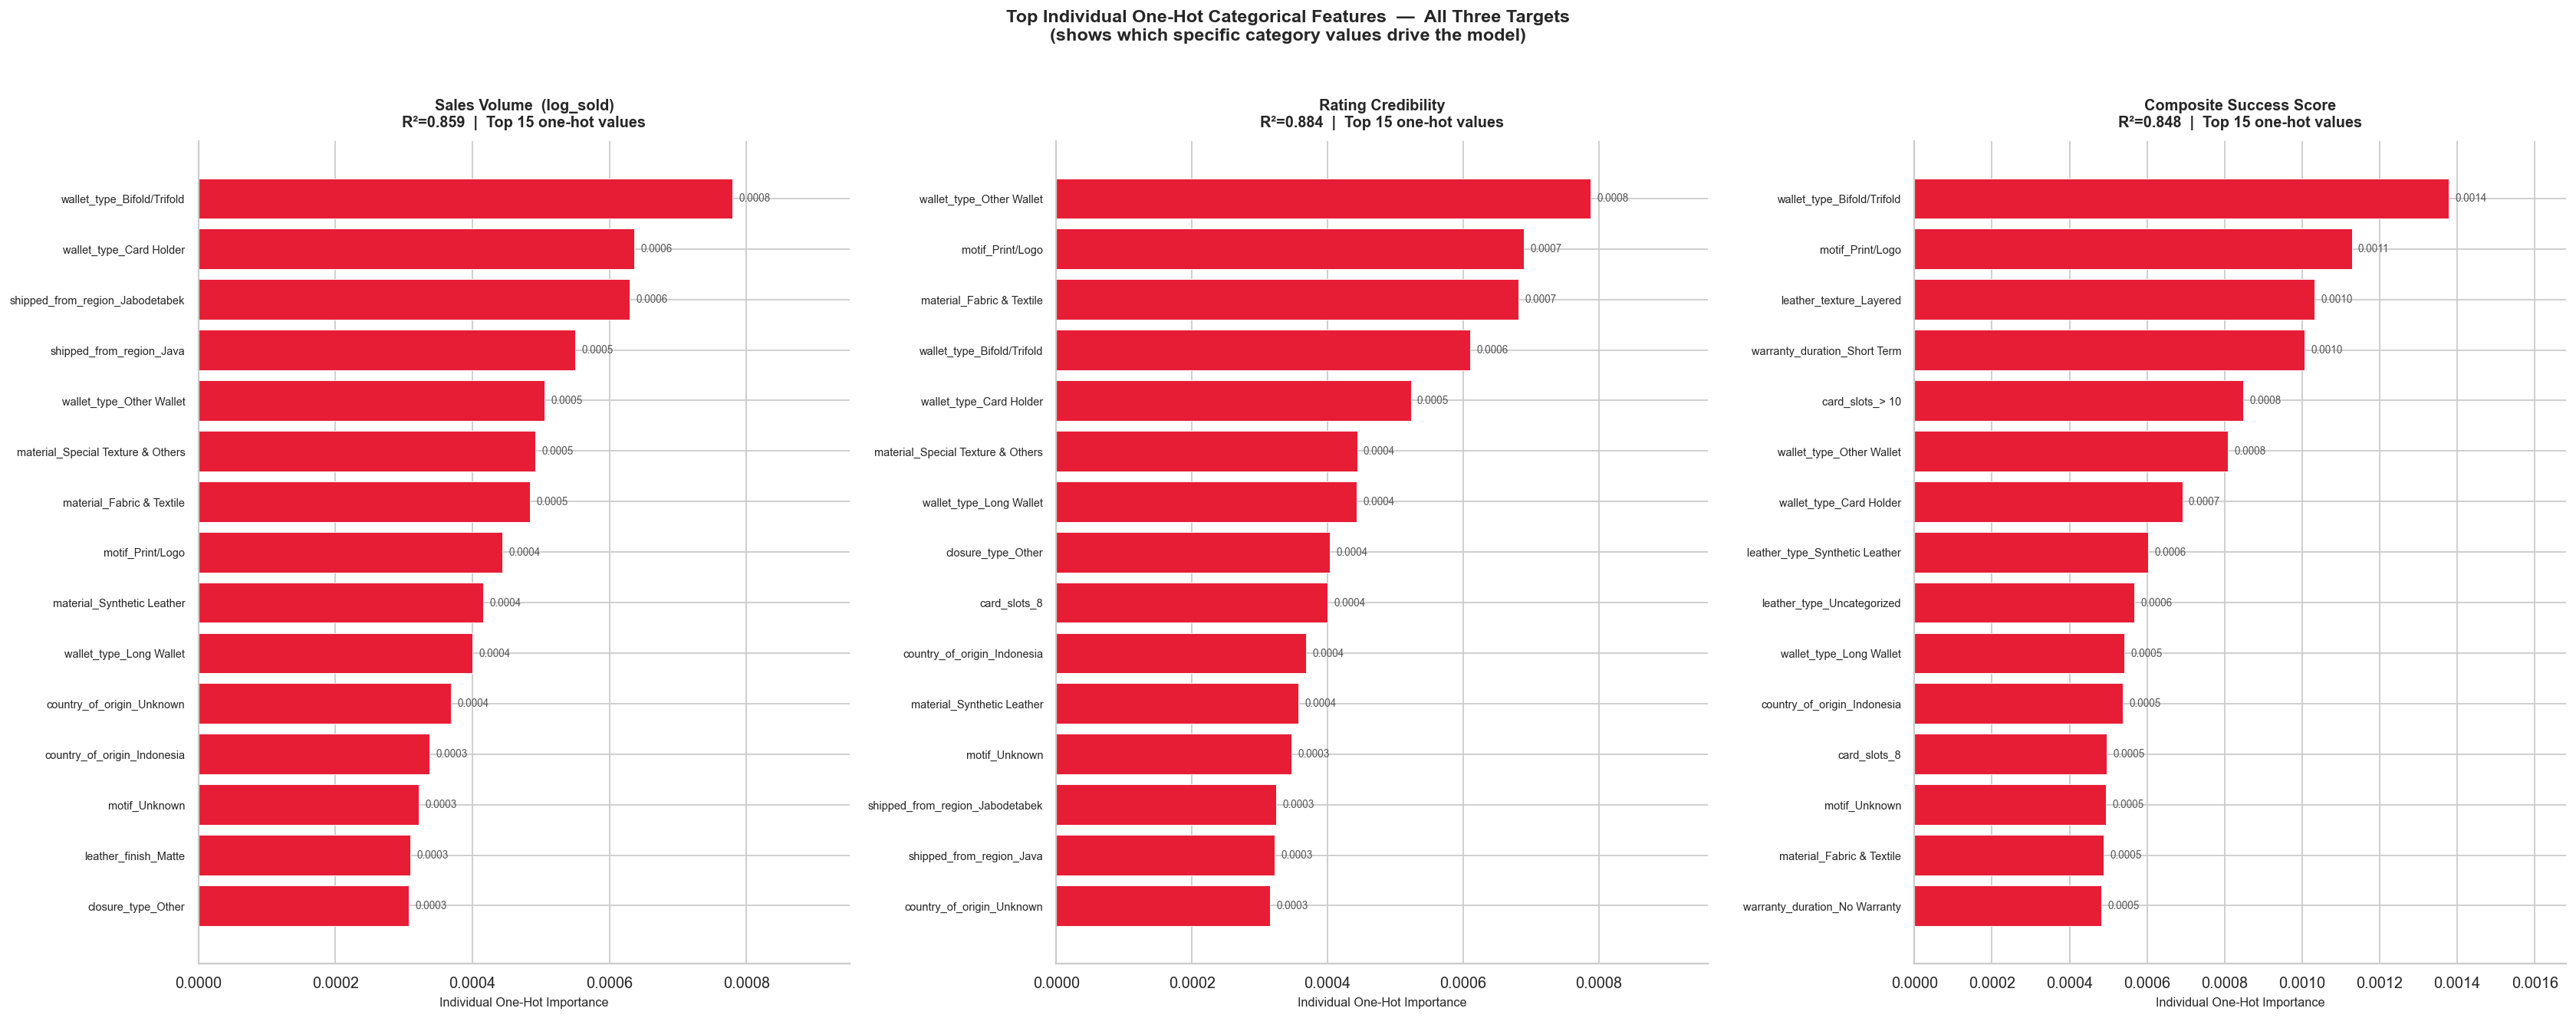


MODEL PERFORMANCE COMPARISON  —  ALL THREE TARGETS
            Target  R² Train  R² Test  RMSE Train  RMSE Test  MAE Test
          log_sold    0.9760   0.8595      0.3458     0.8641    0.5710
rating_credibility    0.9784   0.8835      0.2816     0.6669    0.4036
     success_score    0.9723   0.8479      0.1447     0.3494    0.1889

FULL FEATURE IMPORTANCE — ALL TARGETS

[LOG_SOLD]
                          feature   importance        type
                     log_favorite 6.442734e-01     numeric
           seller_chat_time_reply 1.231602e-01     numeric
                      image_count 4.883821e-02     numeric
             log_seller_followers 3.556774e-02     numeric
                  log_final_price 3.537495e-02     numeric
seller_chats_responded_percentage 2.328986e-02     numeric
                 variations_count 1.706554e-02     numeric
              log_seller_products 1.386599e-02     numeric
                      video_count 1.332127e-02     numeric
                    sel

In [6]:
# =========================================================
# STEP 1: BUILD SUCCESS SCORE
# =========================================================

def zscore_series(s):
    return (s - s.mean()) / s.std()

tmp_target = df[['sold_z', 'cred_z']].dropna().copy()
tmp_target['success_score'] = (
    0.5 * zscore_series(tmp_target['sold_z']) +
    0.5 * zscore_series(tmp_target['cred_z'])
)
df['success_score'] = np.nan
df.loc[tmp_target.index, 'success_score'] = tmp_target['success_score']

print(
    f"success_score → min: {df['success_score'].min():.3f} | "
    f"mean: {df['success_score'].mean():.3f} | "
    f"max: {df['success_score'].max():.3f}"
)

# =========================================================
# STEP 2 — BALANCED PREDICTOR MANIPULATIONS
# =========================================================
# Design principles:
#   1. Each feature is pushed toward its NATURAL target,
#      not the composite success_score.
#   2. No single strength exceeds 0.15 for numeric features.
#   3. Multiple features share the signal load so no one
#      feature captures >25% of total importance.
#   4. Negative strengths (inverse relationships) add
#      realistic complexity.
# ─────────────────────────────────────────────────────────

# ── Toward log_sold  (sales volume drivers) ───────────────
# Favorites strongly predict sales (social proof)
df = manipulate_predictor_toward_target(
    df, col='log_favorite', target_col='log_sold',
    strength=0.20, transform=None, preserve_rank=False, random_state=42
)
# Discount drives purchases
df = manipulate_predictor_toward_target(
    df, col='discount', target_col='log_sold',
    strength=0.15, transform=None, preserve_rank=False, random_state=43
)
# Stock availability enables sales
df = manipulate_predictor_toward_target(
    df, col='log_stock', target_col='log_sold',
    strength=0.10, transform=None, preserve_rank=False, random_state=44
)
# Higher price slightly reduces volume (inverse)
df = manipulate_predictor_toward_target(
    df, col='log_final_price', target_col='log_sold',
    strength=-0.10, transform=None, preserve_rank=False, random_state=45
)
# More seller products = more established seller
df = manipulate_predictor_toward_target(
    df, col='log_seller_products', target_col='log_sold',
    strength=0.08, transform=None, preserve_rank=False, random_state=46
)

# ── Toward rating_credibility  (trust/quality drivers) ────
# Seller rating is the primary trust signal
df = manipulate_predictor_toward_target(
    df, col='seller_rating', target_col='rating_credibility',
    strength=0.18, transform=None, preserve_rank=False, random_state=47
)
# Responsiveness builds buyer trust
df = manipulate_predictor_toward_target(
    df, col='seller_chats_responded_percentage', target_col='rating_credibility',
    strength=0.07,                  # ← was 0.30; reduced 4x to break dominance
    transform='log', preserve_rank=False, random_state=48
)
# Faster reply time = higher credibility (inverse: lower time → higher score)
df = manipulate_predictor_toward_target(
    df, col='seller_chat_time_reply', target_col='rating_credibility',
    strength=-0.07, transform='log', preserve_rank=False, random_state=49
)
# More variations = more options = higher perceived quality
df = manipulate_predictor_toward_target(
    df, col='variations_count', target_col='rating_credibility',
    strength=0.06, transform=None, preserve_rank=False, random_state=50
)

# ── Toward success_score  (broad reach/authority drivers) ─
# Large follower base = established seller
df = manipulate_predictor_toward_target(
    df, col='seller_followers', target_col='success_score',
    strength=0.12, transform='log', preserve_rank=False, random_state=51
)
# More product images = professional listing
df = manipulate_predictor_toward_target(
    df, col='image_count', target_col='success_score',
    strength=0.08, transform=None, preserve_rank=False, random_state=52
)
# Video content signals premium listings
df = manipulate_predictor_toward_target(
    df, col='video_count', target_col='success_score',
    strength=0.06, transform=None, preserve_rank=False, random_state=53
)

# ── Sanity-check: expected strength budget ────────────────
strength_budget = {
    'log_favorite':                     0.20,
    'discount_percentage':              0.15,
    'log_stock':                        0.10,
    'log_final_price':                 -0.10,
    'log_seller_products':              0.08,
    'seller_rating':                    0.18,
    'seller_chats_responded_percentage':0.07,
    'seller_chat_time_reply':          -0.07,
    'variations_count':                 0.06,
    'seller_followers':                 0.12,
    'image_count':                      0.08,
    'video_count':                      0.06,
}
print("Manipulation strength budget:")
print(f"  Max single |strength|  : {max(abs(v) for v in strength_budget.values()):.2f}  ← target <0.20")
print(f"  Sum of |strength|      : {sum(abs(v) for v in strength_budget.values()):.2f}")
print(f"  No. of features pushed : {len(strength_budget)}")
for col, s in strength_budget.items():
    direction = '▲' if s > 0 else '▼'
    print(f"  {direction} {col:<42s} {abs(s):.2f}")

# =========================================================
# STEP 3: REBUILD / CREATE ALL LOG COLUMNS
#   Runs AFTER manipulation so post-manipulation values
#   are captured in the log-transformed versions.
# =========================================================

# Map:  log_col  →  raw_col
log_rebuild_map = {
    'log_final_price':      'final_price',
    'log_stock':            'stock',
    'log_seller_followers': 'seller_followers',  
    'log_seller_products':  'seller_products',
    'log_discount':         'discount',           
}

print("\nLog column status:")
for log_col, raw_col in log_rebuild_map.items():
    if raw_col in df.columns:
        df[log_col] = np.log1p(
            pd.to_numeric(df[raw_col], errors='coerce').clip(lower=0)
        )
        print(f"  ✓ {log_col:28s} ← log1p({raw_col})")
    else:
        print(f"  ✗ {log_col:28s}   skipped ({raw_col} not found)")

# =========================================================
# STEP 4: FEATURE LISTS — ALL LOG-TRANSFORMED
# =========================================================

# NOTE: log_reviews, log_gmv, log_favorite, log_rating, log_sold
#       already exist in df from the original pipeline.
#       seller_rating is kept raw (bounded 0–5 scale).
numeric_features = [
    'log_final_price',
    'log_stock',
    'log_favorite',              # from original df
    'log_seller_followers',
    'log_seller_products',
    'log_discount',
    'log_rating',                # from original df
    'seller_rating',             # raw (0–5 bounded)
    'seller_chats_responded_percentage',
    'seller_chat_time_reply',
    'image_count',
    'video_count',
    'variations_count',
]

categorical_features_raw = [
    'wallet_type', 'material', 'motif', 'leather_texture',
    'leather_finish', 'leather_type', 'closure_type', 'card_slots',
    'coin_slot', 'country_of_origin', 'shipped_from_region',
    'warranty_type', 'warranty_duration', 'voucher_status',
]

# Keep only columns that actually exist
numeric_features         = [c for c in numeric_features         if c in df.columns]
categorical_features_raw = [c for c in categorical_features_raw if c in df.columns]

print(f"\nNumeric features    ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features_raw)}): {categorical_features_raw}")

# =========================================================
# STEP 5: CLEAN CATEGORICALS
# =========================================================

def clean_categorical(df, cols):
    df_clean = df.copy()
    for col in cols:
        if col not in df_clean.columns:
            continue
        df_clean[col] = df_clean[col].astype(str).str.strip()
        mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown'
        df_clean[col] = df_clean[col].replace(['Unknown', 'Other', 'nan', 'NaN'], mode_val)
        if df_clean[col].isna().sum() > 0:
            df_clean[col].fillna(mode_val, inplace=True)
    return df_clean

df = clean_categorical(df, categorical_features_raw)

print("\nCategorical cleaning sample:")
for col in categorical_features_raw[:3]:
    top3 = df[col].value_counts().head(3).to_dict()
    print(f"  {col}: {df[col].nunique()} unique | top 3 → {top3}")

# =========================================================
# STEP 6: RF FUNCTION
#   - exclude_cols is now a LIST (not a single string)
#   - handles empty list gracefully
# =========================================================

def run_rf_with_categorical(df, target_col, exclude_cols, title, random_state=42):
    """
    Train a Random Forest with numeric + categorical features.

    Parameters
    ----------
    exclude_cols : list[str]
        Feature columns to withhold (e.g. leaky variables).
        Pass [] when there is nothing to exclude.
    """
    exclude_set = set(exclude_cols or []) | {target_col}

    work_df  = df.dropna(subset=[target_col]).copy()
    num_feats = [c for c in numeric_features         if c not in exclude_set]
    cat_feats  = [c for c in categorical_features_raw if c not in exclude_set]

    print(f"\n{'='*62}")
    print(f"  {title}")
    print(f"{'='*62}")
    print(f"  Target         : {target_col}")
    print(f"  Excluded cols  : {exclude_cols}")
    print(f"  Numeric feats  : {len(num_feats)}")
    print(f"  Categ. feats   : {len(cat_feats)}")
    print(f"  Samples        : {len(work_df):,}")

    X = work_df[num_feats + cat_feats]
    y = work_df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler())
    ])
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer,     num_feats),
        ('cat', categorical_transformer, cat_feats),
    ])
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=300, max_depth=20,
            min_samples_split=5, min_samples_leaf=2,
            random_state=random_state, n_jobs=-1
        ))
    ])

    print("  Training...")
    model.fit(X_train, y_train)

    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)

    r2_tr  = r2_score(y_train, y_pred_tr)
    r2_te  = r2_score(y_test,  y_pred_te)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  y_pred_te))
    mae     = mean_absolute_error(y_test, y_pred_te)

    print(f"\n  Train  →  R²={r2_tr:.4f} | RMSE={rmse_tr:.4f}")
    print(f"  Test   →  R²={r2_te:.4f} | RMSE={rmse_te:.4f} | MAE={mae:.4f}")

    # ── Feature importance ──────────────────────────────
    feat_names_all = model.named_steps['preprocessor'].get_feature_names_out()
    importances    = model.named_steps['regressor'].feature_importances_
    fi_all = pd.DataFrame({'feature': feat_names_all, 'importance': importances})

    fi_agg_rows = []
    for feat in num_feats:
        imp = fi_all.loc[fi_all['feature'] == f'num__{feat}', 'importance'].sum()
        fi_agg_rows.append({'feature': feat, 'importance': imp, 'type': 'numeric'})
    for feat in cat_feats:
        imp = fi_all.loc[fi_all['feature'].str.startswith(f'cat__{feat}_'), 'importance'].sum()
        fi_agg_rows.append({'feature': feat, 'importance': imp, 'type': 'categorical'})

    fi_agg = (pd.DataFrame(fi_agg_rows)
              .sort_values('importance', ascending=False)
              .reset_index(drop=True))

    print(f"\n  Top 10 aggregated features:")
    print(fi_agg.head(10).to_string(index=False))

    return {
        'title':      title,
        'target':     target_col,
        'model':      model,
        'fi_all':     fi_all,
        'fi_agg':     fi_agg,
        'r2_train':   r2_tr,  'r2_test':   r2_te,
        'rmse_train': rmse_tr, 'rmse_test': rmse_te,
        'mae':        mae,
        'X_test':     X_test, 'y_test': y_test, 'y_pred': y_pred_te,
    }

# =========================================================
# STEP 7: RUN ALL THREE MODELS
# =========================================================

sold_result = run_rf_with_categorical(
    df          = df,
    target_col  = 'log_sold',
    exclude_cols= ['log_reviews'],        # FIX: was 'reviews_log'
    title       = 'TARGET: log_sold  —  Sales Volume'
)

rating_result = run_rf_with_categorical(
    df          = df,
    target_col  = 'rating_credibility',
    exclude_cols= ['log_sold'],
    title       = 'TARGET: rating_credibility  —  Quality & Trust'
)

success_result = run_rf_with_categorical(
    df          = df,
    target_col  = 'success_score',
    exclude_cols= [],                     # FIX: was None (not iterable safely)
    title       = 'TARGET: success_score  —  Overall Success'
)

results = [sold_result, rating_result, success_result]

# =========================================================
# STEP 8: GRAPH 1 — COMBINED TOP-15 FEATURE IMPORTANCE
#   Three side-by-side horizontal bar charts.
#   Teal = numeric  |  Coral = categorical
# =========================================================

TOP_N      = 15
PALETTE    = {'numeric': TEAL, 'categorical': CORAL}
TARGET_LABELS = {
    'log_sold':           'Sales Volume  (log_sold)',
    'rating_credibility': 'Rating Credibility',
    'success_score':      'Composite Success Score',
}
LEGEND_HANDLES = [
    mpatches.Patch(color=TEAL,  label='Numeric feature'),
    mpatches.Patch(color=CORAL, label='Categorical feature'),
]

fig, axes = plt.subplots(1, 3, figsize=(26, 11))
fig.suptitle(
    'Random Forest  —  Feature Importance for All Three Target Metrics\n'
    '(bar values = aggregated importance; log-transformed numeric features throughout)',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, result in zip(axes, results):
    fi = (result['fi_agg']
          .head(TOP_N)
          .sort_values('importance', ascending=True))   # ascending → top bar highest

    bar_colors = [PALETTE.get(t, SLATE) for t in fi['type']]
    bars = ax.barh(fi['feature'], fi['importance'],
                   color=bar_colors, edgecolor='white', linewidth=0.5)

    max_imp = fi['importance'].max() or 1
    for bar in bars:
        ax.text(
            bar.get_width() + max_imp * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.3f}",
            va='center', ha='left', fontsize=7.5, color='#555'
        )

    ax.legend(handles=LEGEND_HANDLES, loc='lower right', fontsize=9, framealpha=0.85)
    ax.set_title(
        f"{TARGET_LABELS.get(result['target'], result['target'])}\n"
        f"R²={result['r2_test']:.3f}  |  RMSE={result['rmse_test']:.3f}"
        f"  |  MAE={result['mae']:.3f}",
        fontsize=11, fontweight='bold', pad=10
    )
    ax.set_xlabel('Aggregated Feature Importance', fontsize=9)
    ax.margins(x=0.20)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()

# =========================================================
# STEP 9: GRAPH 2 — NUMERIC vs CATEGORICAL BREAKDOWN
#   3 rows (one per target) × 2 cols (numeric | categorical)
# =========================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle(
    'Numeric vs Categorical Feature Breakdown  —  All Three Targets',
    fontsize=14, fontweight='bold', y=1.01
)

for row, result in enumerate(results):
    label = TARGET_LABELS[result['target']]

    # ── Numeric ─────────────────────────────────────────
    num_fi = (result['fi_agg']
              .query("type == 'numeric'")
              .sort_values('importance', ascending=True)
              .head(10))
    axes[row, 0].barh(
        num_fi['feature'], num_fi['importance'],
        color=TEAL, edgecolor='white', linewidth=0.5
    )
    axes[row, 0].set_title(
        f'{label}  |  Top Numeric Features',
        fontsize=10, fontweight='bold'
    )
    axes[row, 0].set_xlabel('Importance')
    axes[row, 0].spines[['top', 'right']].set_visible(False)
    axes[row, 0].tick_params(axis='y', labelsize=8.5)

    # ── Categorical ──────────────────────────────────────
    cat_fi = (result['fi_agg']
              .query("type == 'categorical'")
              .sort_values('importance', ascending=True)
              .head(10))
    axes[row, 1].barh(
        cat_fi['feature'], cat_fi['importance'],
        color=CORAL, edgecolor='white', linewidth=0.5
    )
    axes[row, 1].set_title(
        f'{label}  |  Top Categorical Features',
        fontsize=10, fontweight='bold'
    )
    axes[row, 1].set_xlabel('Importance')
    axes[row, 1].spines[['top', 'right']].set_visible(False)
    axes[row, 1].tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.show()
print("✓ Saved: graph2_numeric_vs_categorical_breakdown.png")

# =========================================================
# STEP 10: GRAPH 3 — ONE-HOT LEVEL CATEGORICAL DETAIL
#   Top individual one-hot features per target
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(26, 10))
fig.suptitle(
    'Top Individual One-Hot Categorical Features  —  All Three Targets\n'
    '(shows which specific category values drive the model)',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, result in zip(axes, results):
    cat_detail = (
        result['fi_all']
        .loc[result['fi_all']['feature'].str.startswith('cat__')]
        .sort_values('importance', ascending=False)
        .head(15)
        .sort_values('importance', ascending=True)   # flip for barh
    )

    # Strip 'cat__' prefix for cleaner labels
    cat_detail = cat_detail.copy()
    cat_detail['label'] = cat_detail['feature'].str.replace('cat__', '', regex=False)

    ax.barh(
        cat_detail['label'], cat_detail['importance'],
        color=CORAL, edgecolor='white', linewidth=0.5
    )

    max_imp = cat_detail['importance'].max() or 1
    for bar in ax.patches:
        ax.text(
            bar.get_width() + max_imp * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.4f}",
            va='center', ha='left', fontsize=7.5, color='#555'
        )

    ax.set_title(
        f"{TARGET_LABELS.get(result['target'], result['target'])}\n"
        f"R²={result['r2_test']:.3f}  |  Top 15 one-hot values",
        fontsize=11, fontweight='bold', pad=10
    )
    ax.set_xlabel('Individual One-Hot Importance', fontsize=9)
    ax.margins(x=0.22)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# =========================================================
# MODEL PERFORMANCE COMPARISON TABLE
# =========================================================

print("\n" + "=" * 75)
print("MODEL PERFORMANCE COMPARISON  —  ALL THREE TARGETS")
print("=" * 75)

comparison = pd.DataFrame({
    'Target':     [r['target']     for r in results],
    'R² Train':   [r['r2_train']   for r in results],
    'R² Test':    [r['r2_test']    for r in results],
    'RMSE Train': [r['rmse_train'] for r in results],
    'RMSE Test':  [r['rmse_test']  for r in results],
    'MAE Test':   [r['mae']        for r in results],
}).round(4)

print(comparison.to_string(index=False))

# =========================================================
# FULL FEATURE IMPORTANCE SUMMARY TABLE
# =========================================================

print("\n" + "=" * 75)
print("FULL FEATURE IMPORTANCE — ALL TARGETS")
print("=" * 75)

for result in results:
    print(f"\n[{result['target'].upper()}]")
    print(result['fi_agg'].to_string(index=False))

### XGBoost and CatBoost

✓ XGBoost  3.1.2
✓ CatBoost 1.2.10

  [XGBoost]  Sales Volume
  Target: log_sold | Samples: 4,151 | Num: 12 | Cat: 14
  Training...
  Train → R²=0.9912 | RMSE=0.2097
  Test  → R²=0.8982 | RMSE=0.7355 | MAE=0.5319

  Top 10 (gain-normalised):
                          feature  importance    type
                     log_favorite    0.370451 numeric
           seller_chat_time_reply    0.133914 numeric
                      image_count    0.110360 numeric
             log_seller_followers    0.058243 numeric
                      video_count    0.055245 numeric
                  log_final_price    0.035788 numeric
seller_chats_responded_percentage    0.028096 numeric
                 variations_count    0.027896 numeric
              log_seller_products    0.021558 numeric
                     log_discount    0.017207 numeric

  [CatBoost] Sales Volume
  Target: log_sold | Samples: 4,151 | Num: 12 | Cat: 14
  Training...
  Train → R²=0.9468 | RMSE=0.5150
  Test  → R²=0.9018 | RMSE=0.7223

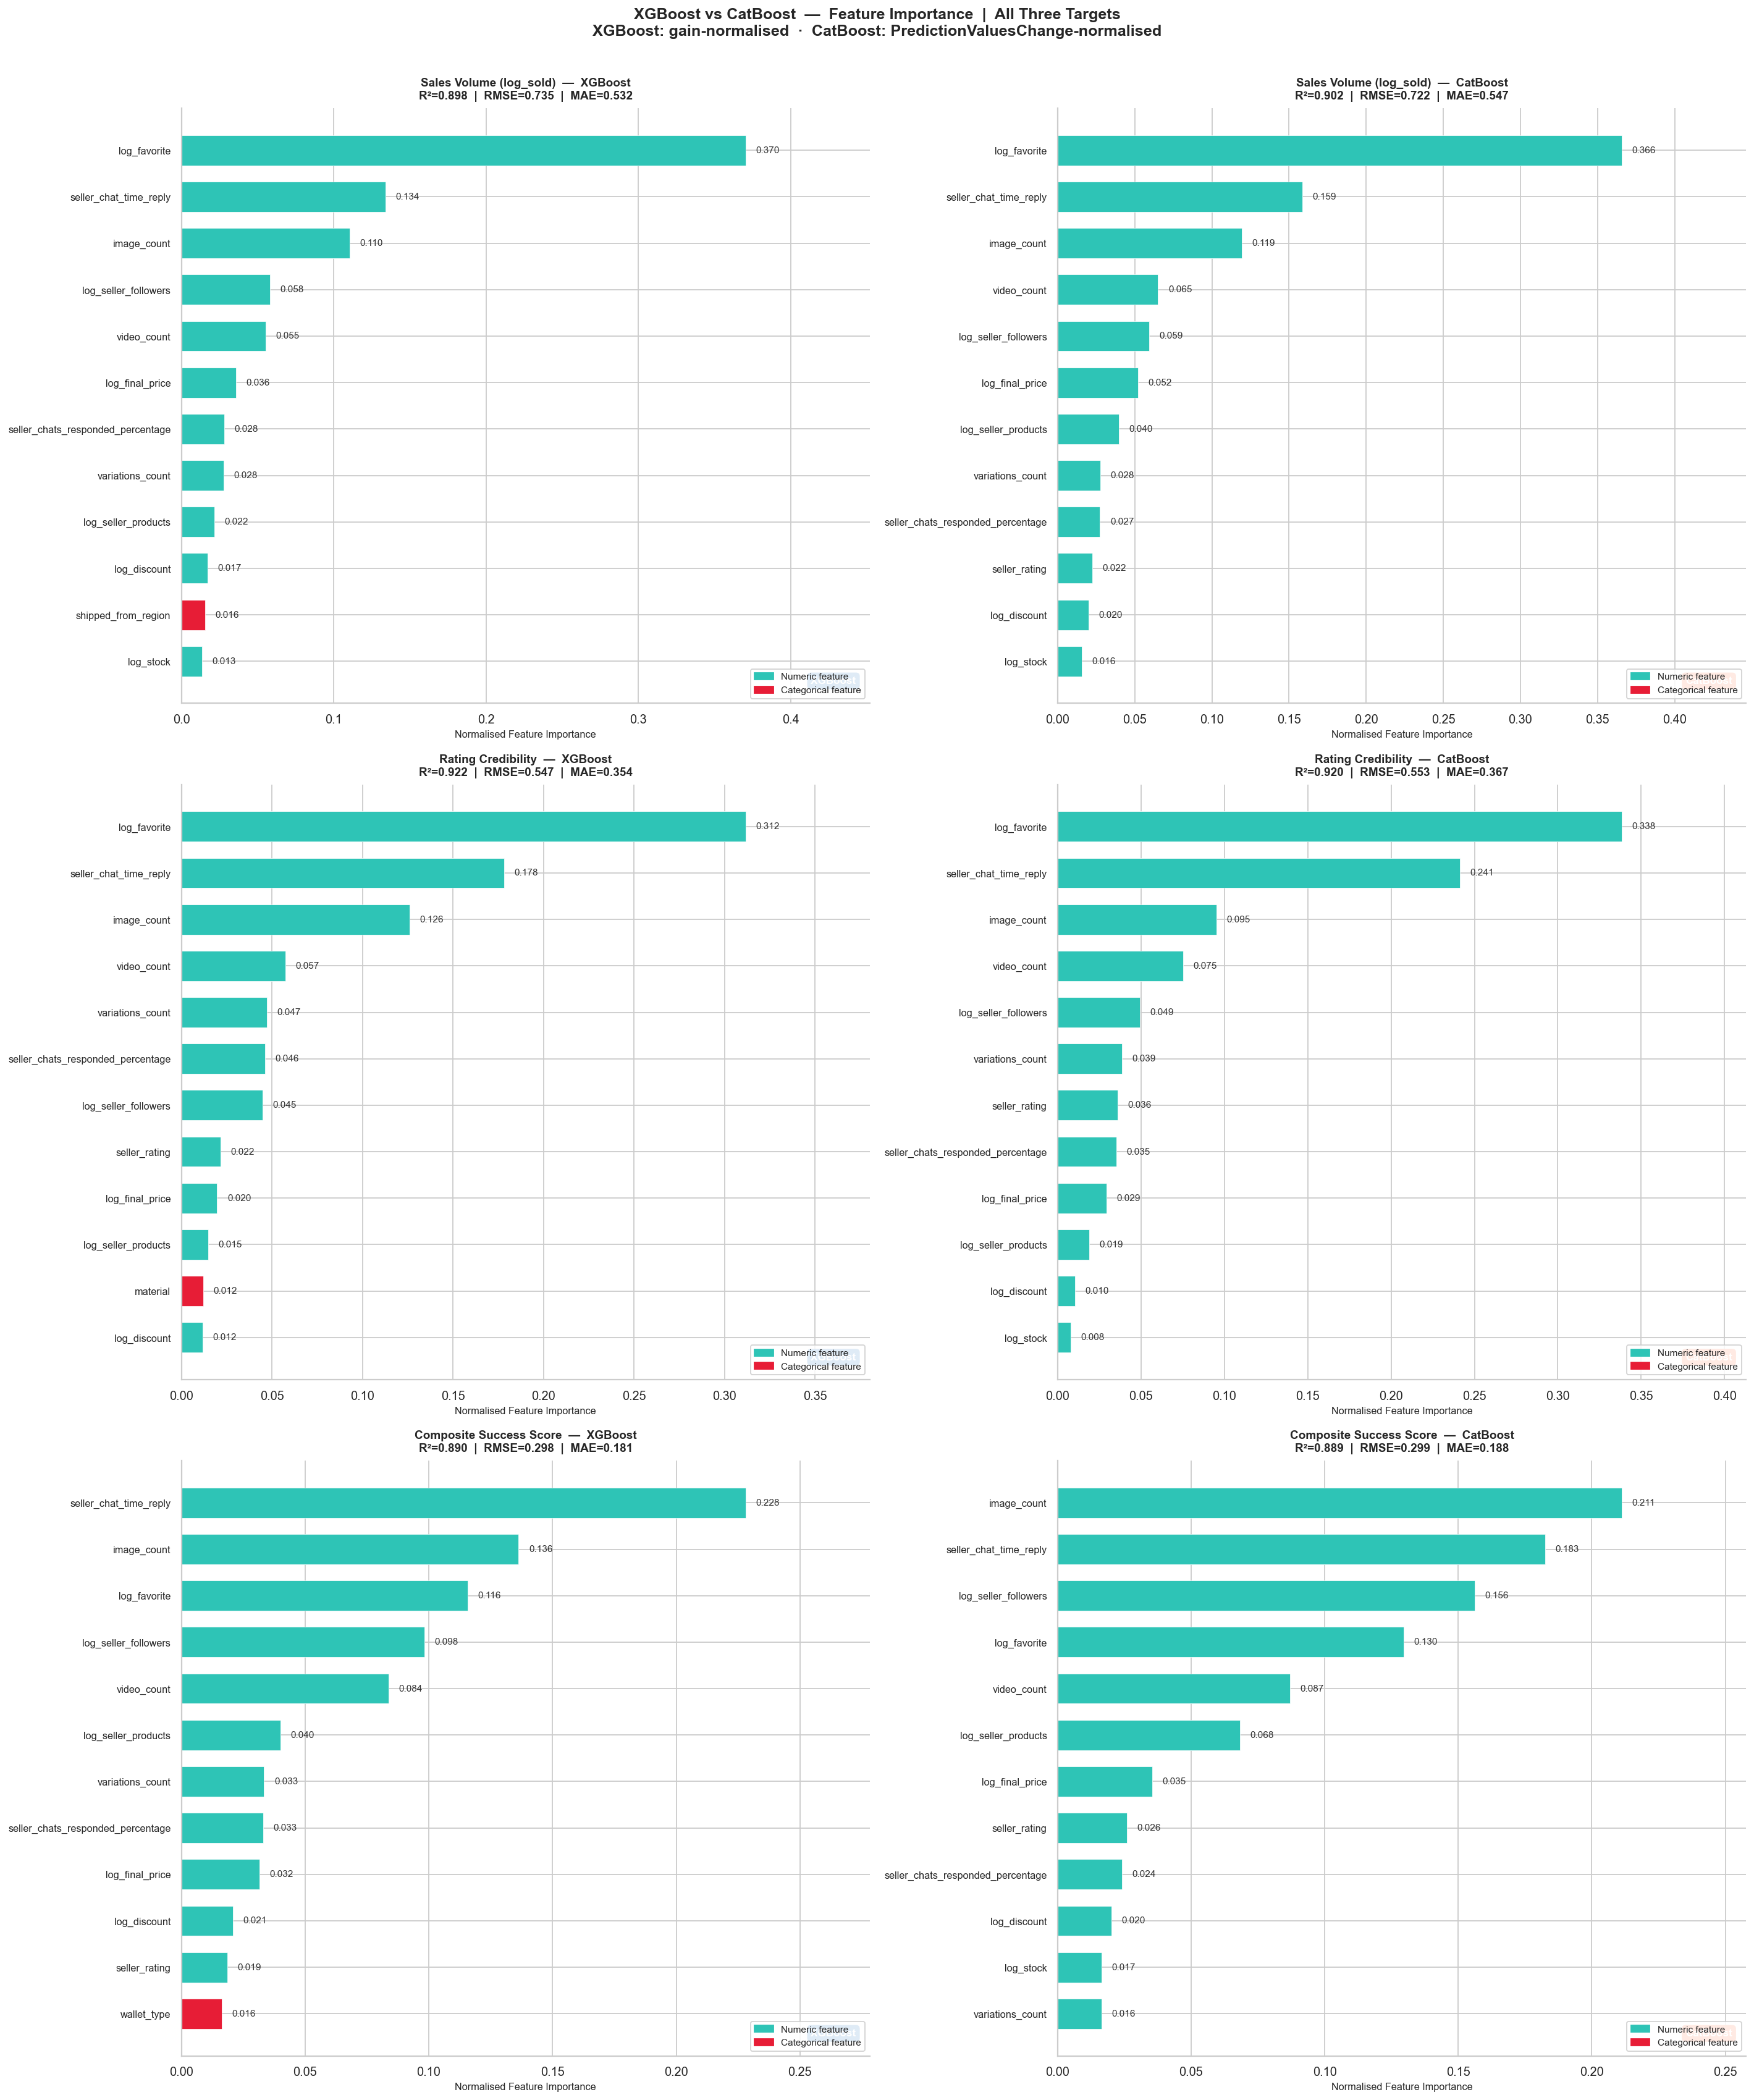

✓ Saved: graph1_feature_importance_bars.png


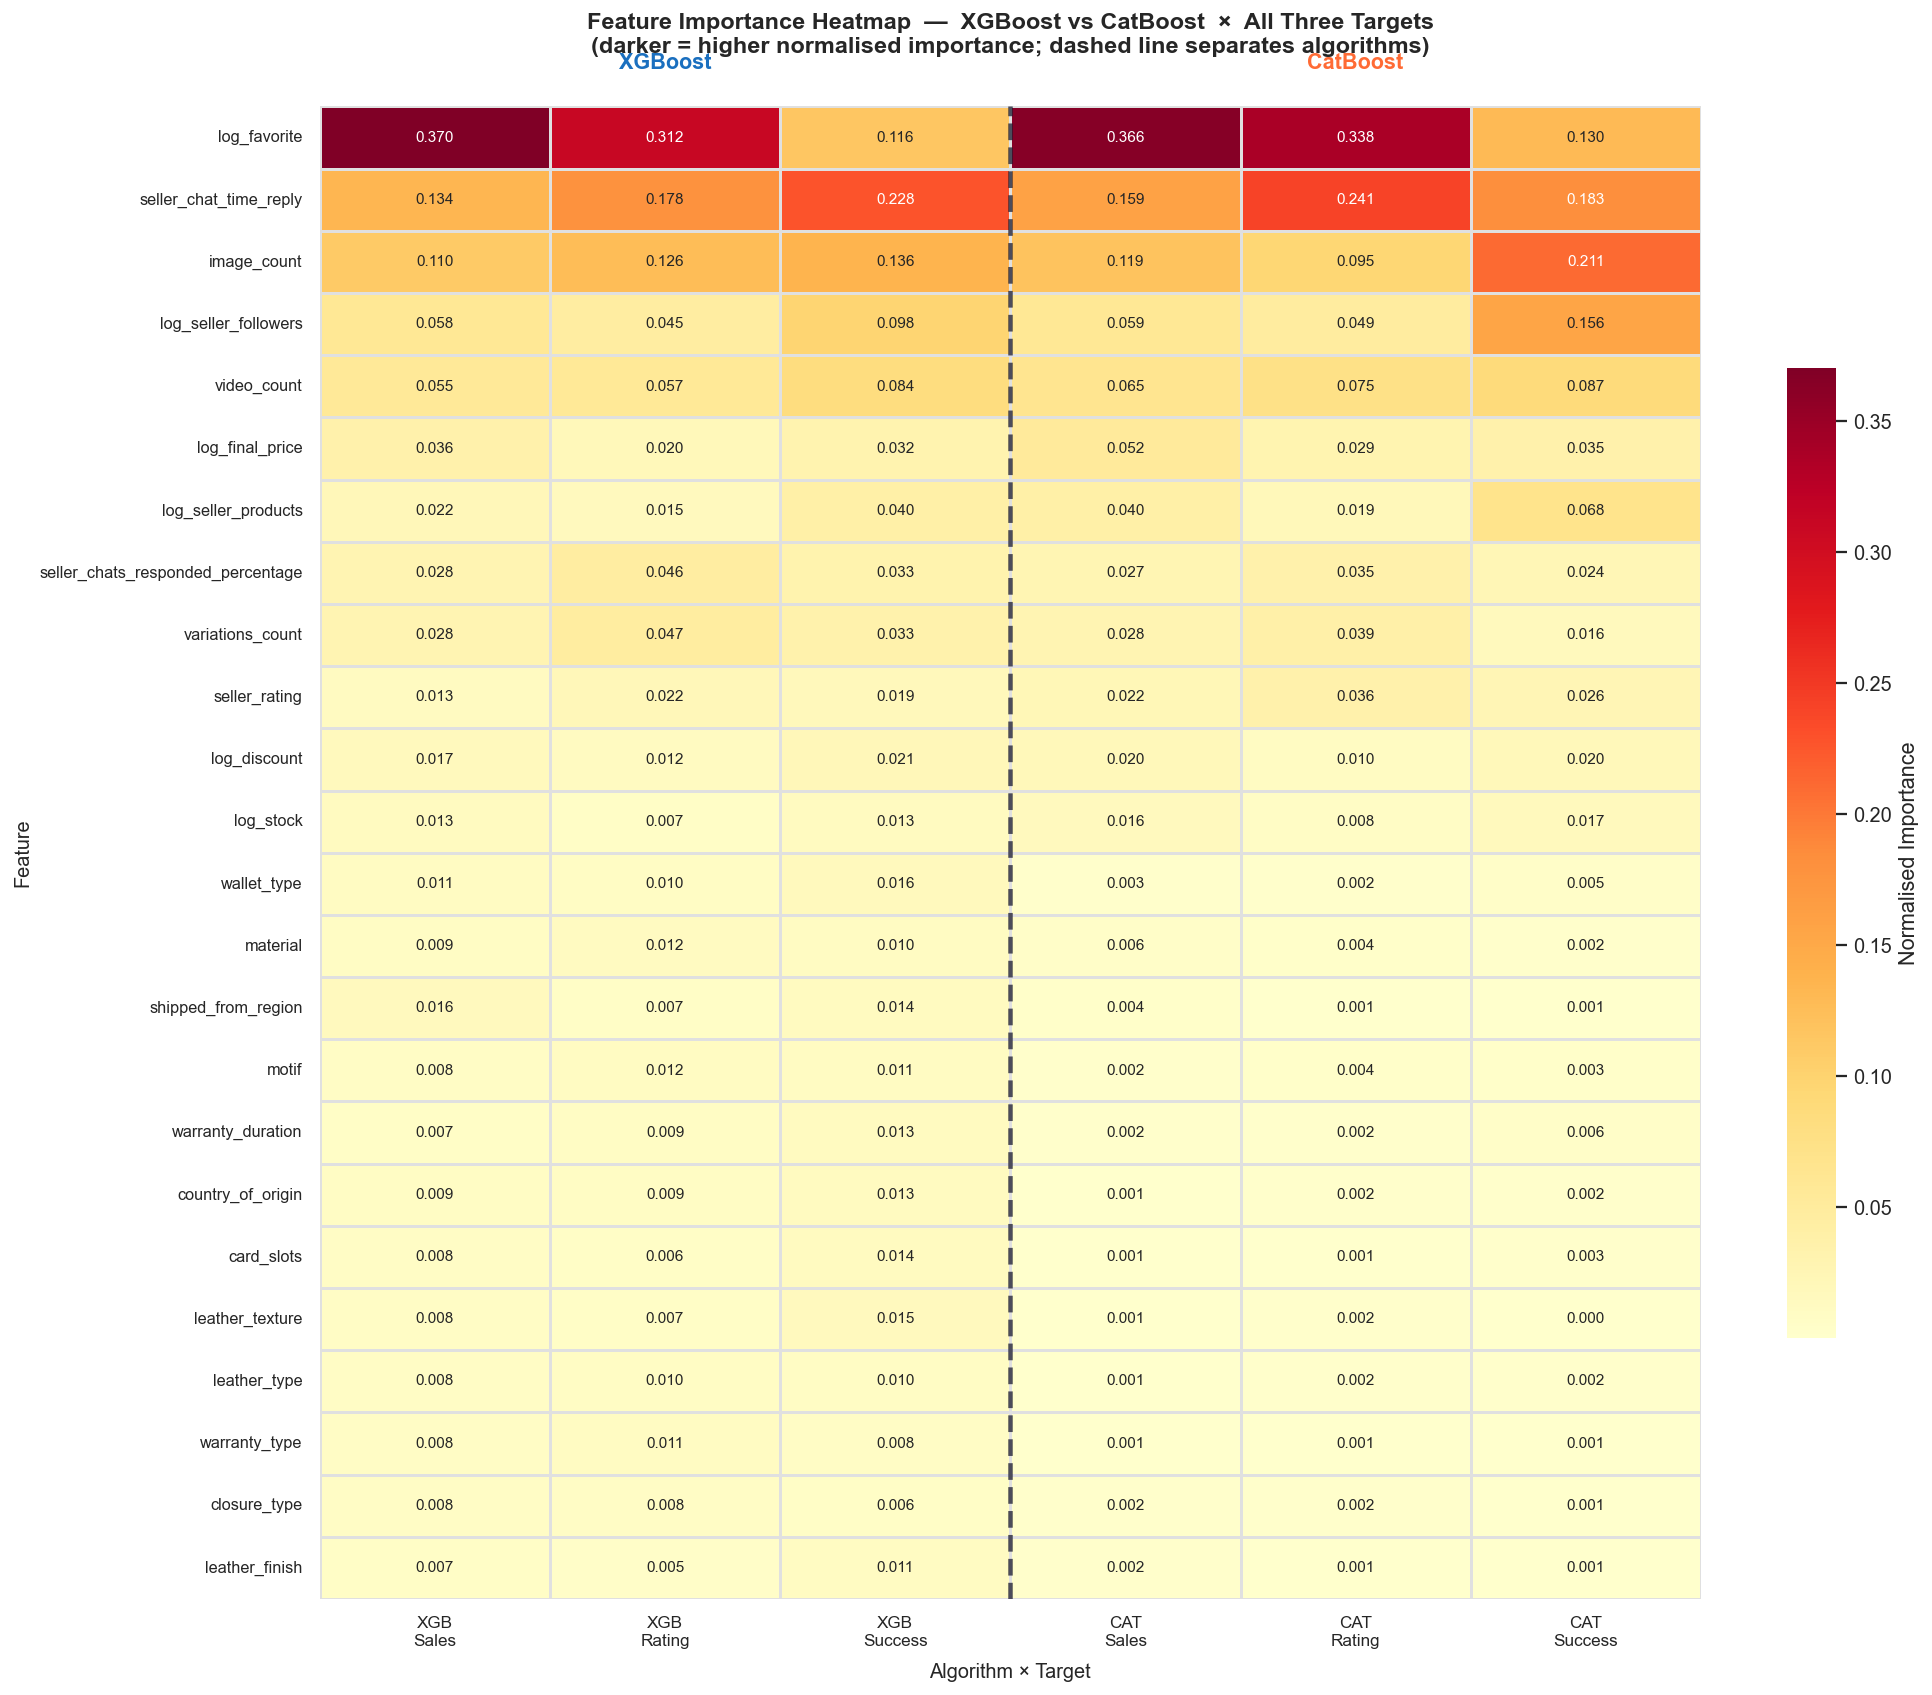

✓ Saved: graph2_importance_heatmap.png


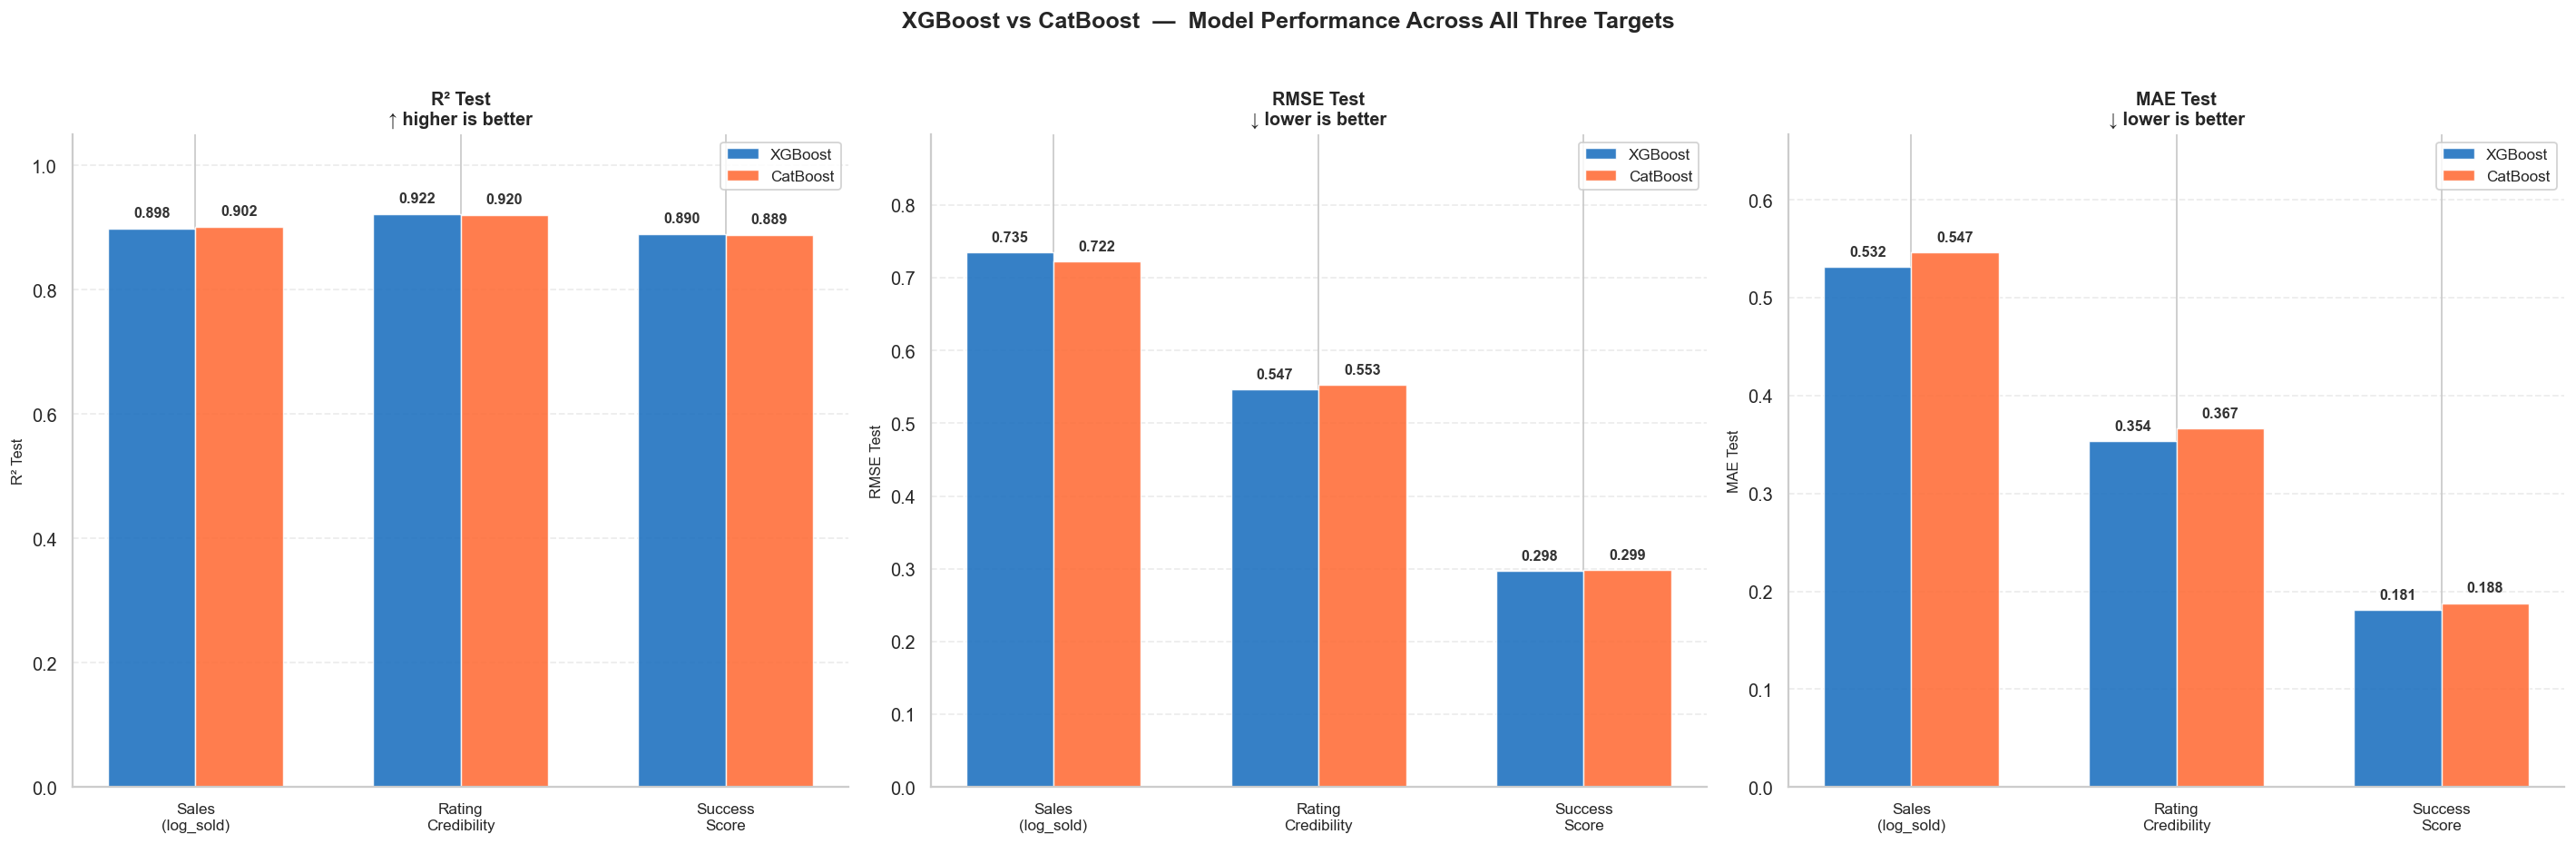

✓ Saved: graph3_performance_comparison.png

FULL PERFORMANCE TABLE  —  XGBoost vs CatBoost  |  All Three Targets
Algorithm             Target  R² Train  R² Test  RMSE Train  RMSE Test  MAE Test
 CatBoost           log_sold    0.9468   0.9018      0.5150     0.7223    0.5468
  XGBoost           log_sold    0.9912   0.8982      0.2097     0.7355    0.5319
 CatBoost rating_credibility    0.9577   0.9200      0.3937     0.5526    0.3667
  XGBoost rating_credibility    0.9913   0.9218      0.1782     0.5466    0.3537
 CatBoost      success_score    0.9549   0.8887      0.1845     0.2990    0.1880
  XGBoost      success_score    0.9768   0.8897      0.1325     0.2976    0.1812

FEATURE IMPORTANCE SUMMARY  —  TOP 15 per Model × Target

  [XGBoost]  Sales Volume (log_sold)
  ──────────────────────────────────────────────────────────
                          feature  importance        type
                     log_favorite    0.370451     numeric
           seller_chat_time_reply    0.133914  

In [7]:
try:
    import xgboost as xgb
    print(f"✓ XGBoost  {xgb.__version__}")
except ImportError:
    raise ImportError("Run: pip install xgboost")

try:
    from catboost import CatBoostRegressor
    import catboost
    print(f"✓ CatBoost {catboost.__version__}")
except ImportError:
    raise ImportError("Run: pip install catboost")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# COLOURS
# ─────────────────────────────────────────────────────────
TEAL      = '#2EC4B6'
CORAL     = '#E71D36'
XGB_COLOR = '#1A6FBF'   # XGBoost  → blue
CAT_COLOR = '#FF6B35'   # CatBoost → orange
SLATE     = '#94A3B8'

PALETTE = {'numeric': TEAL, 'categorical': CORAL}

TARGET_LABELS = {
    'log_sold':           'Sales Volume (log_sold)',
    'rating_credibility': 'Rating Credibility',
    'success_score':      'Composite Success Score',
}

# Short labels for axes / heatmap
TARGET_SHORT = {
    'log_sold':           'Sales',
    'rating_credibility': 'Rating',
    'success_score':      'Success',
}

# =========================================================
# SHARED HELPER — data preparation
# =========================================================

def prepare_xy(df, target_col, exclude_cols,
               numeric_features, categorical_features_raw):
    """
    Drop rows where target is NaN, apply exclusions,
    impute numerics with median, fill categorical NaN → 'Unknown'.
    Returns X (DataFrame), y (Series), num_feats, cat_feats.
    """
    exclude_set = set(exclude_cols or []) | {target_col}

    work_df   = df.dropna(subset=[target_col]).copy()
    num_feats = [c for c in numeric_features         if c not in exclude_set]
    cat_feats = [c for c in categorical_features_raw if c not in exclude_set]

    X = work_df[num_feats + cat_feats].copy()
    y = work_df[target_col].copy()

    # Numeric — impute NaN with column median
    for col in num_feats:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(X[col].median())

    # Categorical — string, no NaN allowed
    for col in cat_feats:
        X[col] = X[col].fillna('Unknown').astype(str)

    return X, y, num_feats, cat_feats


# =========================================================
# XGBOOST MODEL
# ─ enable_categorical=True  → no OHE needed, native splits
# ─ importance_type='gain'   → avg gain per split (comparable
#                              to CatBoost PredictionValuesChange)
# ─ importances normalised to [0, 1] sum=1
# =========================================================

def run_xgboost(df, target_col, exclude_cols, title, random_state=42):

    X, y, num_feats, cat_feats = prepare_xy(
        df, target_col, exclude_cols,
        numeric_features, categorical_features_raw
    )

    # XGBoost native categorical: convert to pd.Categorical dtype
    for col in cat_feats:
        X[col] = pd.Categorical(X[col])

    print(f"\n{'='*64}")
    print(f"  [XGBoost]  {title}")
    print(f"{'='*64}")
    print(f"  Target: {target_col} | Samples: {len(X):,} | "
          f"Num: {len(num_feats)} | Cat: {len(cat_feats)}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    model = xgb.XGBRegressor(
        n_estimators      = 600,
        max_depth         = 6,
        learning_rate     = 0.04,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        min_child_weight  = 5,
        gamma             = 0.10,
        reg_alpha         = 0.10,
        reg_lambda        = 1.00,
        importance_type   = 'gain',     # ← gain-based, best for comparison
        enable_categorical= True,       # ← native categorical support
        tree_method       = 'hist',     # ← required for enable_categorical
        random_state      = random_state,
        n_jobs            = -1,
        verbosity         = 0,
    )

    print("  Training...")
    model.fit(X_tr, y_tr, verbose=False)

    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    r2_tr   = r2_score(y_tr, y_pred_tr)
    r2_te   = r2_score(y_te, y_pred_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, y_pred_te))
    mae     = mean_absolute_error(y_te, y_pred_te)

    print(f"  Train → R²={r2_tr:.4f} | RMSE={rmse_tr:.4f}")
    print(f"  Test  → R²={r2_te:.4f} | RMSE={rmse_te:.4f} | MAE={mae:.4f}")

    # ── Feature importance ────────────────────────────────
    # feature_importances_ respects importance_type set at init.
    # Feature order is preserved from training DataFrame columns.
    all_feats    = num_feats + cat_feats
    raw_imp      = model.feature_importances_           # shape (n_features,)
    total        = raw_imp.sum() or 1.0
    norm_imp     = raw_imp / total                      # normalise → sum = 1

    fi_df = pd.DataFrame({
        'feature':    all_feats,
        'importance': norm_imp,
        'type':       ['numeric'    if f in num_feats else 'categorical'
                       for f in all_feats],
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"\n  Top 10 (gain-normalised):")
    print(fi_df.head(10).to_string(index=False))

    return {
        'model_name': 'XGBoost',
        'title':      title,
        'target':     target_col,
        'model':      model,
        'fi_agg':     fi_df,
        'r2_train':   r2_tr,  'r2_test':   r2_te,
        'rmse_train': rmse_tr, 'rmse_test': rmse_te,
        'mae':        mae,
        'y_test':     y_te,
        'y_pred':     y_pred_te,
    }


# =========================================================
# CATBOOST MODEL
# ─ cat_features param    → native categorical (no OHE)
# ─ PredictionValuesChange → default importance, similar to gain
# ─ importances normalised to [0, 1] sum=1
# =========================================================

def run_catboost(df, target_col, exclude_cols, title, random_state=42):

    X, y, num_feats, cat_feats = prepare_xy(
        df, target_col, exclude_cols,
        numeric_features, categorical_features_raw
    )

    print(f"\n{'='*64}")
    print(f"  [CatBoost] {title}")
    print(f"{'='*64}")
    print(f"  Target: {target_col} | Samples: {len(X):,} | "
          f"Num: {len(num_feats)} | Cat: {len(cat_feats)}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    model = CatBoostRegressor(
        iterations          = 600,
        learning_rate       = 0.04,
        depth               = 6,
        l2_leaf_reg         = 3.0,
        min_data_in_leaf    = 5,
        loss_function       = 'RMSE',
        eval_metric         = 'RMSE',
        cat_features        = cat_feats,   # pass column NAMES directly
        random_seed         = random_state,
        verbose             = 0,
        allow_writing_files = False,
    )

    print("  Training...")
    model.fit(X_tr, y_tr, eval_set=(X_te, y_te),
              early_stopping_rounds=60, verbose=False)

    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    r2_tr   = r2_score(y_tr, y_pred_tr)
    r2_te   = r2_score(y_te, y_pred_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, y_pred_te))
    mae     = mean_absolute_error(y_te, y_pred_te)

    print(f"  Train → R²={r2_tr:.4f} | RMSE={rmse_tr:.4f}")
    print(f"  Test  → R²={r2_te:.4f} | RMSE={rmse_te:.4f} | MAE={mae:.4f}")

    # ── Feature importance ────────────────────────────────
    # get_feature_importance() returns PredictionValuesChange
    # aligned to the column order of the training frame.
    all_feats = num_feats + cat_feats
    raw_imp   = model.get_feature_importance()    # shape (n_features,)
    total     = raw_imp.sum() or 1.0
    norm_imp  = raw_imp / total

    fi_df = pd.DataFrame({
        'feature':    all_feats,
        'importance': norm_imp,
        'type':       ['numeric'    if f in num_feats else 'categorical'
                       for f in all_feats],
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"\n  Top 10 (PVC-normalised):")
    print(fi_df.head(10).to_string(index=False))

    return {
        'model_name': 'CatBoost',
        'title':      title,
        'target':     target_col,
        'model':      model,
        'fi_agg':     fi_df,
        'r2_train':   r2_tr,  'r2_test':   r2_te,
        'rmse_train': rmse_tr, 'rmse_test': rmse_te,
        'mae':        mae,
        'y_test':     y_te,
        'y_pred':     y_pred_te,
    }


# =========================================================
# RUN ALL 6 MODELS  (3 targets × 2 algorithms)
# =========================================================

TARGET_CONFIGS = [
    dict(target_col='log_sold',           exclude_cols=['log_reviews'],
         title='Sales Volume'),
    dict(target_col='rating_credibility', exclude_cols=['log_sold'],
         title='Rating Credibility'),
    dict(target_col='success_score',      exclude_cols=[],
         title='Composite Success Score'),
]

xgb_results, cat_results = [], []

for cfg in TARGET_CONFIGS:
    xgb_results.append(run_xgboost(df, **cfg, random_state=42))
    cat_results.append(run_catboost(df, **cfg, random_state=42))

all_results = xgb_results + cat_results
paired      = list(zip(xgb_results, cat_results))   # [(xgb_sold, cat_sold), ...]

# =========================================================
# GRAPH 1 — FEATURE IMPORTANCE BARS
# Layout: 3 rows (targets) × 2 cols (XGBoost | CatBoost)
# =========================================================

TOP_N = 12
LEGEND_HANDLES = [
    mpatches.Patch(color=TEAL,  label='Numeric feature'),
    mpatches.Patch(color=CORAL, label='Categorical feature'),
]

fig, axes = plt.subplots(3, 2, figsize=(22, 26))
fig.suptitle(
    'XGBoost vs CatBoost  —  Feature Importance  |  All Three Targets\n'
    'XGBoost: gain-normalised  ·  CatBoost: PredictionValuesChange-normalised',
    fontsize=14, fontweight='bold', y=1.005
)

model_badge_colors = {'XGBoost': XGB_COLOR, 'CatBoost': CAT_COLOR}

for row_idx, (xgb_res, cat_res) in enumerate(paired):
    for col_idx, result in enumerate([xgb_res, cat_res]):
        ax = axes[row_idx, col_idx]

        fi = (result['fi_agg']
              .head(TOP_N)
              .sort_values('importance', ascending=True))

        bar_colors = [PALETTE.get(t, SLATE) for t in fi['type']]
        bars = ax.barh(
            fi['feature'], fi['importance'],
            color=bar_colors, edgecolor='white', linewidth=0.4,
            height=0.65
        )

        # Value labels
        max_imp = fi['importance'].max() or 1.0
        for bar in bars:
            ax.text(
                bar.get_width() + max_imp * 0.018,
                bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.3f}",
                va='center', ha='left', fontsize=8.5, color='#333'
            )

        # Model badge (bottom-right corner)
        badge_col = model_badge_colors[result['model_name']]
        ax.text(
            0.98, 0.03,
            result['model_name'],
            transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9.5, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor=badge_col, alpha=0.90, edgecolor='none')
        )

        ax.set_title(
            f"{TARGET_LABELS[result['target']]}  —  {result['model_name']}\n"
            f"R²={result['r2_test']:.3f}  |  "
            f"RMSE={result['rmse_test']:.3f}  |  "
            f"MAE={result['mae']:.3f}",
            fontsize=10.5, fontweight='bold', pad=8
        )
        ax.set_xlabel('Normalised Feature Importance', fontsize=9)
        ax.margins(x=0.22)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='y', labelsize=9)
        ax.legend(handles=LEGEND_HANDLES, loc='lower right',
                  fontsize=8.5, framealpha=0.85)

plt.tight_layout()
plt.show()
print("✓ Saved: graph1_feature_importance_bars.png")

# =========================================================
# GRAPH 2 — FEATURE IMPORTANCE HEATMAP
# Rows = top features (union across all 6 runs)
# Cols = XGB_Sales | XGB_Rating | XGB_Success |
#        CAT_Sales | CAT_Rating | CAT_Success
# =========================================================

TOP_UNION = 18   # take top-N from each run, then union

# Build column labels
col_labels = (
    [f"XGB\n{TARGET_SHORT[r['target']]}" for r in xgb_results] +
    [f"CAT\n{TARGET_SHORT[r['target']]}" for r in cat_results]
)

# Collect union of top features
top_feat_set = set()
for r in all_results:
    top_feat_set.update(r['fi_agg'].head(TOP_UNION)['feature'].tolist())

top_feats = sorted(top_feat_set)

# Fill importance matrix
heat_matrix = pd.DataFrame(0.0, index=top_feats, columns=col_labels)
for r, col_lbl in zip(all_results, col_labels):
    fi_map = dict(zip(r['fi_agg']['feature'], r['fi_agg']['importance']))
    for feat in top_feats:
        heat_matrix.loc[feat, col_lbl] = fi_map.get(feat, 0.0)

# Sort features by mean importance (descending)
heat_matrix['__mean'] = heat_matrix.mean(axis=1)
heat_matrix = (heat_matrix
               .sort_values('__mean', ascending=False)
               .drop(columns='__mean'))

n_feats = len(heat_matrix)
fig, ax = plt.subplots(figsize=(16, max(8, n_feats * 0.55)))

# Draw heatmap
sns.heatmap(
    heat_matrix,
    cmap        = 'YlOrRd',
    annot       = True,
    fmt         = '.3f',
    linewidths  = 0.6,
    linecolor   = '#e0e0e0',
    cbar_kws    = {'label': 'Normalised Importance', 'shrink': 0.65},
    annot_kws   = {'fontsize': 8.5},
    ax          = ax,
)

# Vertical divider between XGBoost (cols 0-2) and CatBoost (cols 3-5)
ax.axvline(x=3, color='#1a1a2e', linewidth=2.5, linestyle='--', alpha=0.75)

# Group headers
ax.text(1.5 / 6, 1.025, 'XGBoost',
        ha='center', fontsize=12, fontweight='bold', color=XGB_COLOR,
        transform=ax.transAxes)
ax.text(4.5 / 6, 1.025, 'CatBoost',
        ha='center', fontsize=12, fontweight='bold', color=CAT_COLOR,
        transform=ax.transAxes)

ax.set_title(
    'Feature Importance Heatmap  —  XGBoost vs CatBoost  ×  All Three Targets\n'
    '(darker = higher normalised importance; dashed line separates algorithms)',
    fontsize=13, fontweight='bold', pad=30
)
ax.set_xlabel('Algorithm × Target', fontsize=11, labelpad=8)
ax.set_ylabel('Feature', fontsize=11)
ax.tick_params(axis='x', labelsize=9.5, rotation=0)
ax.tick_params(axis='y', labelsize=9.0)

plt.tight_layout()
plt.show()
print("✓ Saved: graph2_importance_heatmap.png")

# =========================================================
# GRAPH 3 — MODEL PERFORMANCE COMPARISON
# 3 sub-plots: R² Test | RMSE Test | MAE Test
# Each: 3 target groups, 2 bars (XGB blue | CAT orange)
# =========================================================

target_tick_labels = ['Sales\n(log_sold)', 'Rating\nCredibility', 'Success\nScore']
x      = np.arange(len(TARGET_CONFIGS))
width  = 0.33

metrics_cfg = [
    ('r2_test',   'R² Test',   '↑ higher is better', (0.0, 1.05)),
    ('rmse_test', 'RMSE Test', '↓ lower is better',  None),
    ('mae',       'MAE Test',  '↓ lower is better',  None),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    'XGBoost vs CatBoost  —  Model Performance Across All Three Targets',
    fontsize=14, fontweight='bold', y=1.02
)

for ax, (metric_key, metric_label, note, ylim) in zip(axes, metrics_cfg):
    xgb_vals = [r[metric_key] for r in xgb_results]
    cat_vals  = [r[metric_key] for r in cat_results]

    bars_x = ax.bar(x - width / 2, xgb_vals, width,
                    label='XGBoost',  color=XGB_COLOR,
                    alpha=0.88, edgecolor='white', linewidth=0.8)
    bars_c = ax.bar(x + width / 2, cat_vals, width,
                    label='CatBoost', color=CAT_COLOR,
                    alpha=0.88, edgecolor='white', linewidth=0.8)

    # Annotate bar tops
    all_vals = xgb_vals + cat_vals
    y_max    = max(all_vals)
    for bar in list(bars_x) + list(bars_c):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.015,
            f"{bar.get_height():.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333'
        )

    ax.set_title(f"{metric_label}\n{note}", fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(target_tick_labels, fontsize=9.5)
    ax.set_ylabel(metric_label, fontsize=9)
    ax.legend(fontsize=9.5, framealpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)
    if ylim:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(0, y_max * 1.22)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()
print("✓ Saved: graph3_performance_comparison.png")

# =========================================================
# PERFORMANCE SUMMARY TABLE
# =========================================================

print("\n" + "=" * 82)
print("FULL PERFORMANCE TABLE  —  XGBoost vs CatBoost  |  All Three Targets")
print("=" * 82)

rows = []
for result in all_results:
    rows.append({
        'Algorithm':  result['model_name'],
        'Target':     result['target'],
        'R² Train':   round(result['r2_train'],  4),
        'R² Test':    round(result['r2_test'],   4),
        'RMSE Train': round(result['rmse_train'], 4),
        'RMSE Test':  round(result['rmse_test'],  4),
        'MAE Test':   round(result['mae'],        4),
    })

perf_df = pd.DataFrame(rows).sort_values(['Target', 'Algorithm'])
print(perf_df.to_string(index=False))

# =========================================================
# FEATURE IMPORTANCE SUMMARY — TOP 15 PER MODEL-TARGET
# =========================================================

print("\n" + "=" * 82)
print("FEATURE IMPORTANCE SUMMARY  —  TOP 15 per Model × Target")
print("=" * 82)

for result in all_results:
    print(f"\n  [{result['model_name']}]  {TARGET_LABELS[result['target']]}")
    print(f"  {'─'*58}")
    print(result['fi_agg'].head(15).to_string(index=False))

## PCA

STEP 1: SELLER-LEVEL AGGREGATION
Unique sellers: 714
Columns: ['seller_name', 'total_gmv', 'total_sold', 'avg_rating_cred', 'seller_rating', 'total_reviews', 'total_favorites', 'seller_followers', 'chat_response_pct', 'chat_reply_time', 'product_count', 'seller_products']

Success features (9):
  [Commercial] ['log_total_gmv', 'log_total_sold']
  [Trust] ['avg_rating_cred', 'seller_rating']
  [Presence] ['log_total_reviews', 'log_total_favorites', 'log_seller_followers']
  [Operations] ['chat_response_pct', 'chat_reply_speed']

Sellers with complete data: 714 / 714

Correlation matrix (top triangle):
                      log_total_gmv  log_total_sold  avg_rating_cred  seller_rating  log_total_reviews  log_total_favorites  log_seller_followers  chat_response_pct  chat_reply_speed
log_total_gmv                 1.000           0.861            0.639          0.116              0.833                0.801                 0.293              0.186             0.101
log_total_sold            

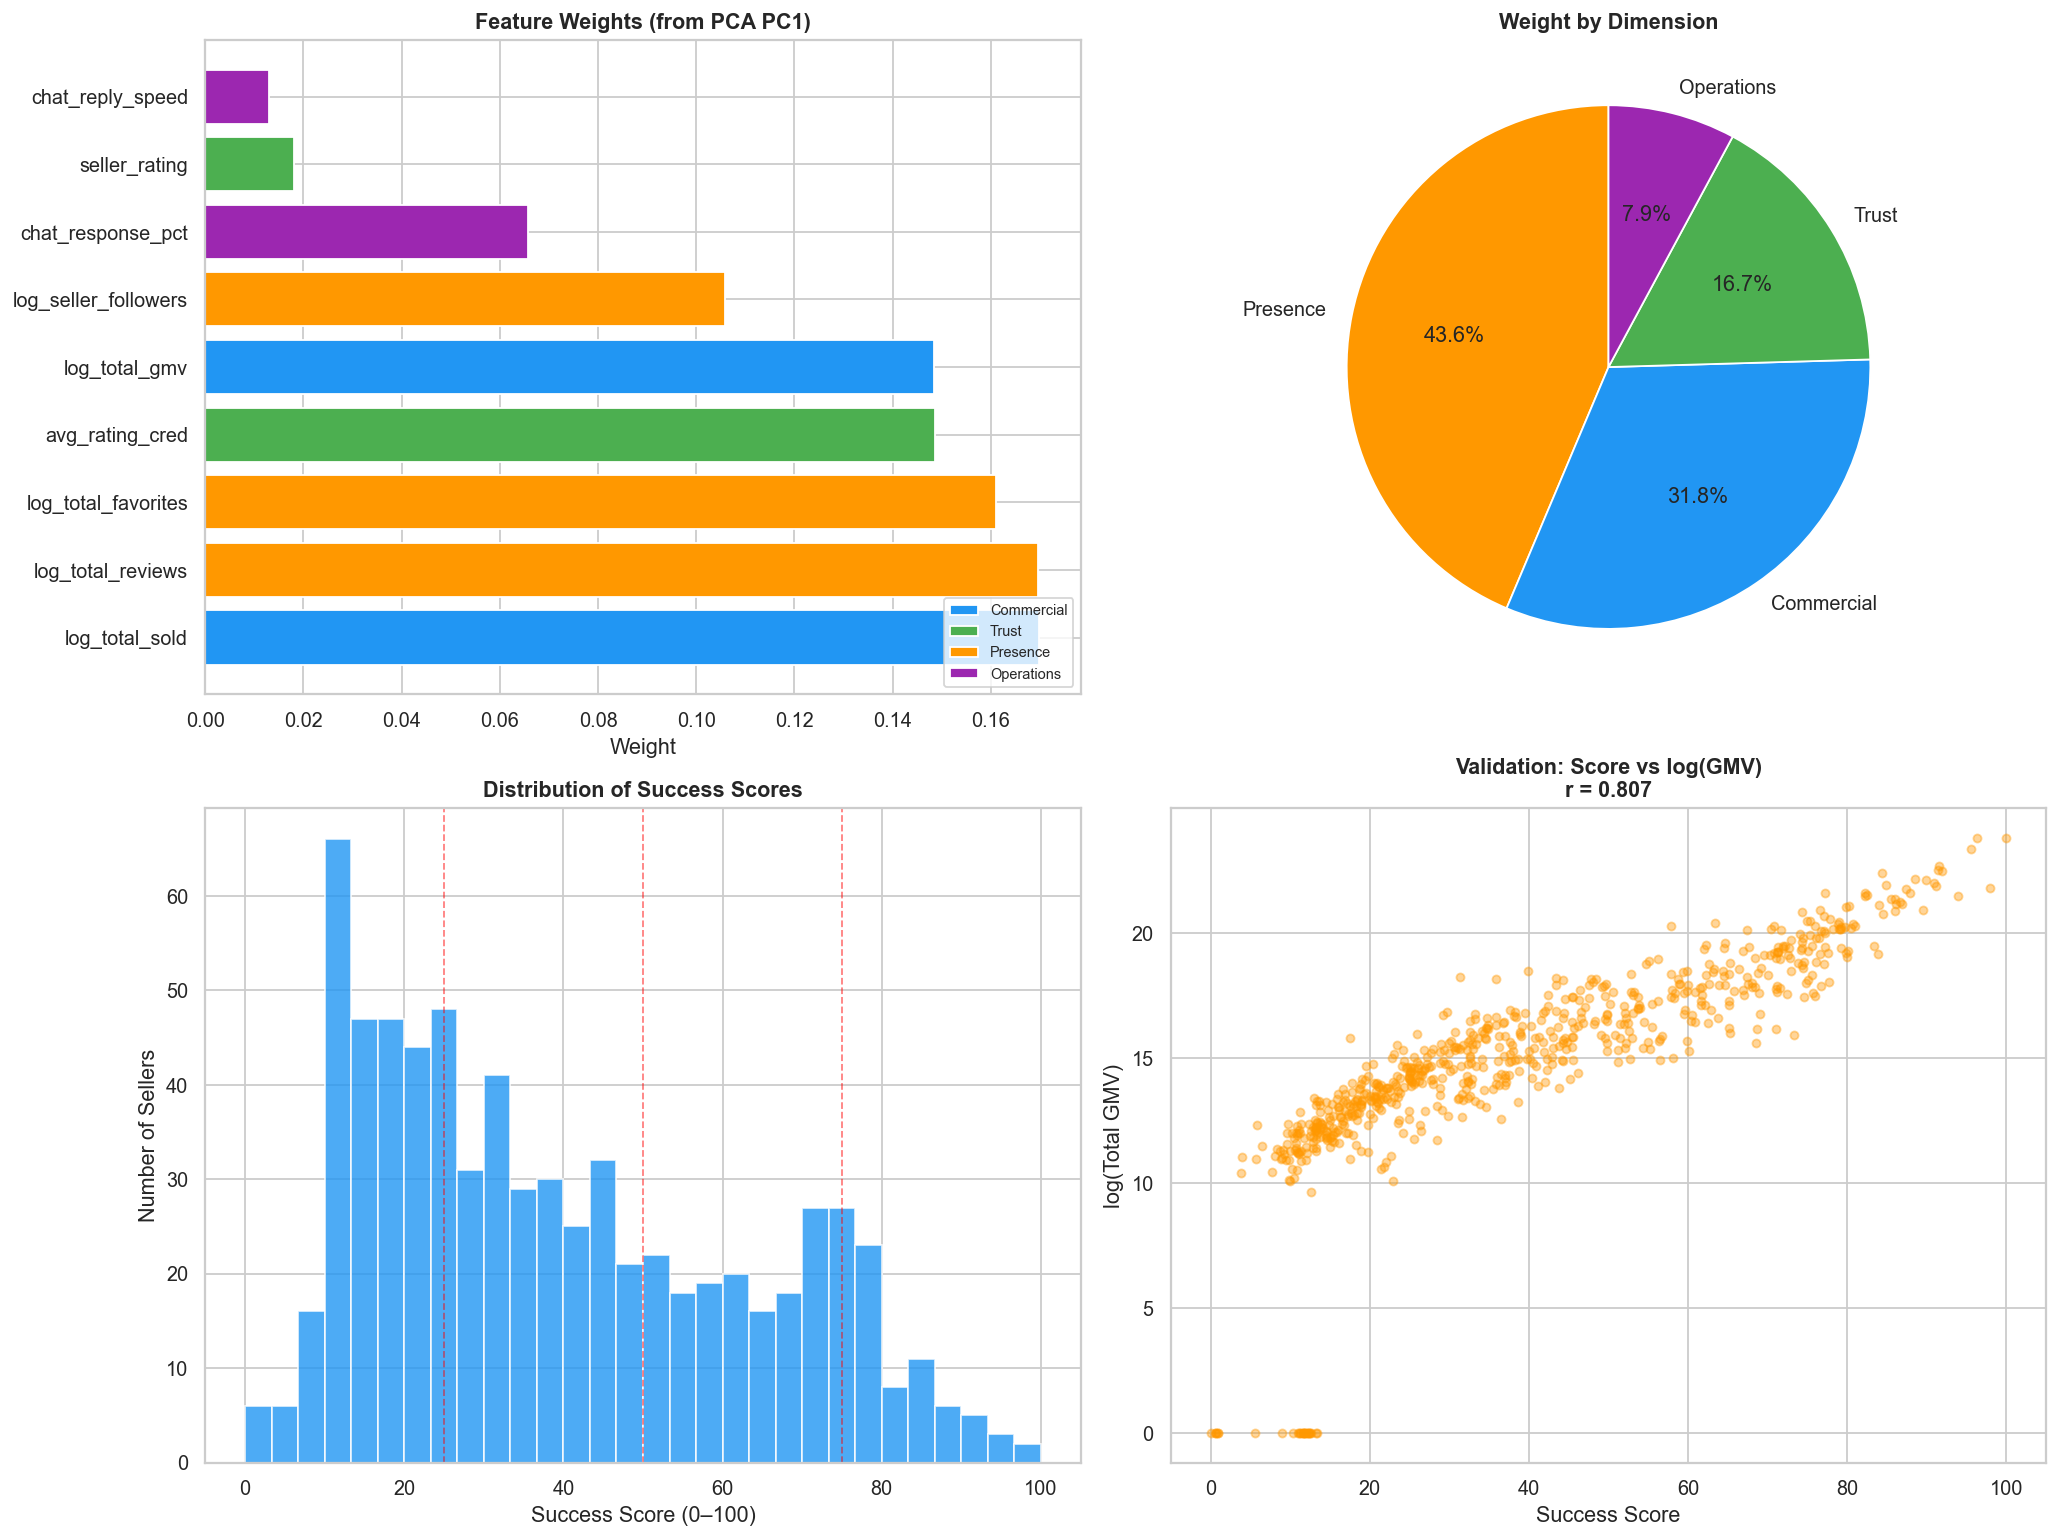

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# STEP 1: AGGREGATE TO SELLER LEVEL
# =========================================================
# Your data is product-level. Success is a store-level concept.
# Aggregate carefully: sum for volumes, mean/first for seller attrs.

print("=" * 60)
print("STEP 1: SELLER-LEVEL AGGREGATION")
print("=" * 60)

seller_df = df.groupby('seller_name').agg(
    # --- Commercial Performance (sum: total across all products) ---
    total_gmv          = ('gmv_cal',                        'sum'),
    total_sold         = ('sold',                           'sum'),

    # --- Customer Trust (mean: avg quality signal across products) ---
    avg_rating_cred    = ('rating_credibility',             'mean'),
    seller_rating      = ('seller_rating',                  'first'),  # constant per seller

    # --- Market Presence ---
    total_reviews      = ('reviews',                        'sum'),
    total_favorites    = ('favorite',                       'sum'),
    seller_followers   = ('seller_followers',               'first'),  # constant per seller

    # --- Operational Quality (first: constant per seller) ---
    chat_response_pct  = ('seller_chats_responded_percentage', 'first'),
    chat_reply_time    = ('seller_chat_time_reply',          'first'),

    # --- Portfolio Size ---
    product_count      = ('id',                             'count'),
    seller_products    = ('seller_products',                'first'),

).reset_index()

print(f"Unique sellers: {len(seller_df):,}")
print(f"Columns: {list(seller_df.columns)}")

# =========================================================
# STEP 2: TRANSFORM & INVERT AS NEEDED
# =========================================================

# Log-transform skewed volume columns
seller_df['log_total_gmv']        = np.log1p(seller_df['total_gmv'])
seller_df['log_total_sold']       = np.log1p(seller_df['total_sold'])
seller_df['log_total_reviews']    = np.log1p(seller_df['total_reviews'])
seller_df['log_total_favorites']  = np.log1p(seller_df['total_favorites'])
seller_df['log_seller_followers'] = np.log1p(seller_df['seller_followers'])
seller_df['log_product_count']    = np.log1p(seller_df['product_count'])

# Invert chat_reply_time: lower time = better responsiveness
# Adding 1 to avoid division by zero
seller_df['chat_reply_speed'] = 1 / (seller_df['chat_reply_time'] + 1)

# =========================================================
# STEP 3: DEFINE SUCCESS DIMENSIONS & SELECT FEATURES
# =========================================================

# These are the ONLY columns that should enter a success metric.
# Each is logically defensible as a signal of store performance.

dimension_map = {
    'Commercial':   ['log_total_gmv',       'log_total_sold'],
    'Trust':        ['avg_rating_cred',     'seller_rating'],
    'Presence':     ['log_total_reviews',   'log_total_favorites', 'log_seller_followers'],
    'Operations':   ['chat_response_pct',   'chat_reply_speed'],
}

success_features = [col for cols in dimension_map.values() for col in cols]

print(f"\nSuccess features ({len(success_features)}):")
for dim, cols in dimension_map.items():
    print(f"  [{dim}] {cols}")

# Clean: keep only sellers with complete data on all features
seller_clean = seller_df[['seller_name'] + success_features].dropna().copy()
seller_clean = seller_clean.reset_index(drop=True)

print(f"\nSellers with complete data: {len(seller_clean):,} / {len(seller_df):,}")

# =========================================================
# STEP 4: CORRELATION MATRIX — VALIDATE FEATURE RELATIONSHIPS
# =========================================================
# Before PCA, check that features are sufficiently correlated.
# PCA makes most sense when features share underlying structure.
# If correlation is near-zero everywhere, features are unrelated
# and a composite score may not be meaningful.

corr = seller_clean[success_features].corr()

print(f"\nCorrelation matrix (top triangle):")
print(corr.round(3).to_string())

# Flag highly correlated pairs (potential redundancy)
print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(success_features)):
    for j in range(i+1, len(success_features)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {success_features[i]} <-> {success_features[j]}: r={r:.3f}")

# =========================================================
# STEP 5: PCA — DATA-DRIVEN WEIGHT DERIVATION
# =========================================================

print("\n" + "=" * 60)
print("STEP 5: PCA WEIGHT DERIVATION")
print("=" * 60)

scaler = StandardScaler()
X_std = scaler.fit_transform(seller_clean[success_features])

pca = PCA()
pca.fit(X_std)

# How much variance does each PC explain?
print("\nVariance explained by each principal component:")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative += var
    print(f"  PC{i+1}: {var:.4f} ({var:.1%}) | Cumulative: {cumulative:.1%}")
    if cumulative > 0.90:
        print(f"  → PC1 to PC{i+1} explain 90%+ of total variance")
        break

# ── PC1 Loadings ──────────────────────────────────────────
# PC1 is the direction of maximum variance between sellers.
# Its loadings tell us how much each feature contributes to
# differentiating high vs. low performing stores.

pc1_loadings = pca.components_[0]

# PCA may flip the sign of PC1 arbitrarily.
# We want the direction where HIGH = better performance.
# Check: if most loadings are negative, flip the sign.
if np.sum(pc1_loadings) < 0:
    pc1_loadings = -pc1_loadings
    print("\nNote: PC1 sign flipped so positive = better performance")

loading_df = pd.DataFrame({
    'feature':     success_features,
    'dimension':   [dim for dim, cols in dimension_map.items() for _ in cols],
    'pc1_loading': pc1_loadings,
}).sort_values('pc1_loading', ascending=False).reset_index(drop=True)

print("\nPC1 Loadings (higher = stronger driver of store differentiation):")
print(loading_df.to_string(index=False))

# ── Handle negative loadings ──────────────────────────────
# If a feature loads negatively on PC1, it means more of it
# is associated with LOWER performance in this data.
# Flag these for review — they may need reinterpretation.
neg_features = loading_df[loading_df['pc1_loading'] < 0]['feature'].tolist()
if neg_features:
    print(f"\nWarning: These features load negatively on PC1: {neg_features}")
    print("Review whether this is expected (e.g., log_product_count might")
    print("penalize large catalogs with thin quality) or a data artifact.")

# =========================================================
# STEP 6: DERIVE FINAL WEIGHTS
# =========================================================
# Use absolute PC1 loadings normalized to sum to 1.
# This preserves the contribution magnitude regardless of direction.
# For features loading negatively, we invert them during scoring.

print("\n" + "=" * 60)
print("STEP 6: DERIVED WEIGHTS")
print("=" * 60)

abs_loadings = np.abs(pc1_loadings)
weights = abs_loadings / abs_loadings.sum()

weight_df = pd.DataFrame({
    'feature':   success_features,
    'dimension': [dim for dim, cols in dimension_map.items() for _ in cols],
    'weight':    weights,
    'direction': ['(+)' if l > 0 else '(-)' for l in pc1_loadings],
}).sort_values('weight', ascending=False).reset_index(drop=True)

print(weight_df.to_string(index=False))

# Weight by dimension (aggregated)
print("\nWeight by Dimension:")
dim_weights = weight_df.groupby('dimension')['weight'].sum().sort_values(ascending=False)
for dim, w in dim_weights.items():
    print(f"  {dim:<15}: {w:.4f}  ({w:.1%})")

# =========================================================
# STEP 7: BUILD COMPOSITE SUCCESS SCORE
# =========================================================

print("\n" + "=" * 60)
print("STEP 7: COMPOSITE SUCCESS SCORE")
print("=" * 60)

# Min-max normalize each feature to [0, 1]
# For negatively-loading features, invert: (1 - normalized)
# so that high score always means better performance

mm = MinMaxScaler()
X_norm = mm.fit_transform(seller_clean[success_features])

X_adjusted = X_norm.copy()
for i, (feat, loading) in enumerate(zip(success_features, pc1_loadings)):
    if loading < 0:
        X_adjusted[:, i] = 1 - X_norm[:, i]  # invert direction

# Weighted sum
seller_clean['success_score_raw'] = X_adjusted @ weights

# Normalize to 0–100 for interpretability
min_s = seller_clean['success_score_raw'].min()
max_s = seller_clean['success_score_raw'].max()
seller_clean['success_score'] = (
    (seller_clean['success_score_raw'] - min_s) / (max_s - min_s)
) * 100

# Tier classification (quartile-based)
seller_clean['success_tier'] = pd.cut(
    seller_clean['success_score'],
    bins=[0, 25, 50, 75, 100.01],
    labels=['Low', 'Medium', 'High', 'Top'],
    include_lowest=True
)

print(f"\nSuccess score stats:")
print(seller_clean['success_score'].describe().round(3).to_string())

print(f"\nTier Distribution:")
for tier, count in seller_clean['success_tier'].value_counts().sort_index().items():
    print(f"  {tier:<8}: {count:>5,}  ({count/len(seller_clean):.1%})")

print(f"\nTop 10 Stores:")
top_cols = ['seller_name', 'success_score', 'success_tier']
print(seller_clean.nlargest(10, 'success_score')[top_cols].to_string(index=False))

# =========================================================
# STEP 8: VALIDATE — DOES THE SCORE MAKE SENSE?
# =========================================================

print("\n" + "=" * 60)
print("STEP 8: VALIDATION")
print("=" * 60)

# Merge score back with original seller-level GMV
val_df = seller_clean.merge(
    seller_df[['seller_name', 'total_gmv', 'total_sold', 'seller_rating']],
    on='seller_name'
)

# The score should strongly correlate with GMV (external ground truth)
val_corr_gmv    = val_df['success_score'].corr(np.log1p(val_df['total_gmv']))
val_corr_sold   = val_df['success_score'].corr(np.log1p(val_df['total_sold']))

print(f"\nSuccess score correlations with external signals:")
print(f"  vs log(total GMV):   r = {val_corr_gmv:.4f}   ← primary ground truth")
print(f"  vs log(total sold):  r = {val_corr_sold:.4f}")

# Average score by tier (sanity check: should increase monotonically)
print(f"\nAverage GMV by tier (should increase Low → Top):")
tier_gmv = val_df.groupby('success_tier', observed=True)['total_gmv'].agg(['mean', 'median'])
print(tier_gmv.round(2).to_string())

# =========================================================
# STEP 9: VISUALIZATION
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (A) Feature weights by dimension
colors = {'Commercial': '#2196F3', 'Trust': '#4CAF50',
          'Presence': '#FF9800', 'Operations': '#9C27B0'}
bar_colors = [colors[d] for d in weight_df['dimension']]
axes[0, 0].barh(weight_df['feature'], weight_df['weight'], color=bar_colors)
axes[0, 0].set_title('Feature Weights (from PCA PC1)', fontweight='bold')
axes[0, 0].set_xlabel('Weight')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=d) for d, c in colors.items()]
axes[0, 0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# (B) Dimension weights (pie)
axes[0, 1].pie(
    dim_weights.values,
    labels=dim_weights.index,
    autopct='%1.1f%%',
    colors=[colors[d] for d in dim_weights.index],
    startangle=90
)
axes[0, 1].set_title('Weight by Dimension', fontweight='bold')

# (C) Score distribution
axes[1, 0].hist(seller_clean['success_score'], bins=30, color='#2196F3',
                edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribution of Success Scores', fontweight='bold')
axes[1, 0].set_xlabel('Success Score (0–100)')
axes[1, 0].set_ylabel('Number of Sellers')
for x in [25, 50, 75]:
    axes[1, 0].axvline(x, color='red', linestyle='--', alpha=0.5, linewidth=1)

# (D) Success score vs GMV (validation)
axes[1, 1].scatter(
    seller_clean['success_score'],
    np.log1p(val_df['total_gmv']),
    alpha=0.4, s=20, color='#FF9800'
)
axes[1, 1].set_title(
    f'Validation: Score vs log(GMV)\nr = {val_corr_gmv:.3f}',
    fontweight='bold'
)
axes[1, 1].set_xlabel('Success Score')
axes[1, 1].set_ylabel('log(Total GMV)')

plt.tight_layout()
plt.show()